Building Energy Optimization System
Physics-based model initialized
Generating virtual datasets...
Running thermal simulation...
Calculating optimal start time...

Optimization Results:
- Predicted startup temperature: 29.3°C
- Required cooling duration: 5 minutes
- Recommended start time: 08:55

Generating analysis visualizations...


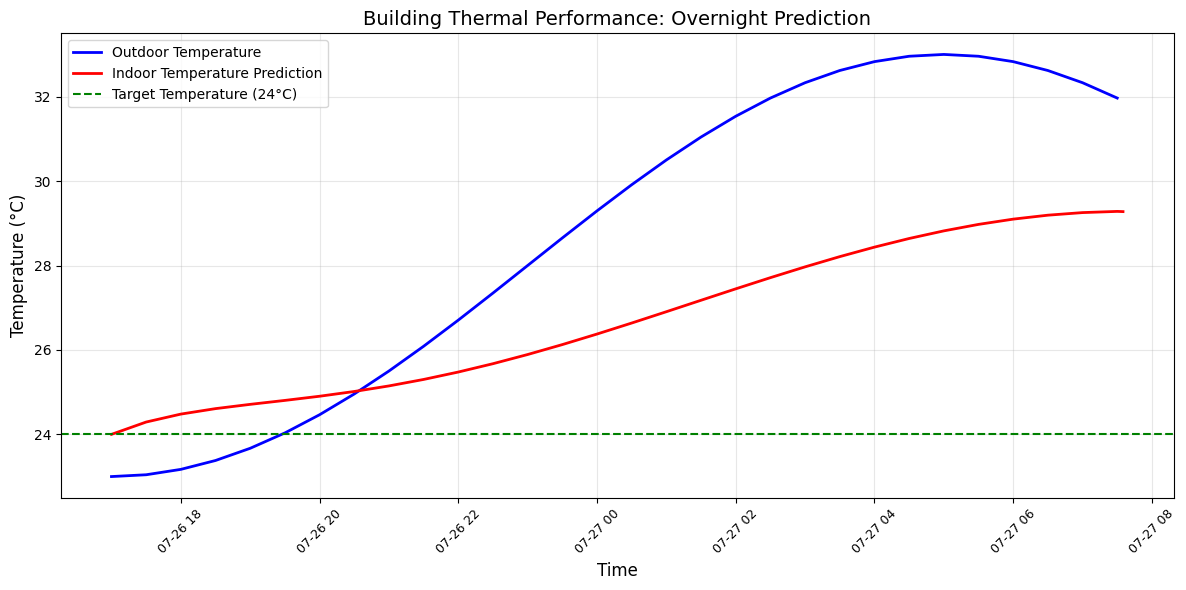

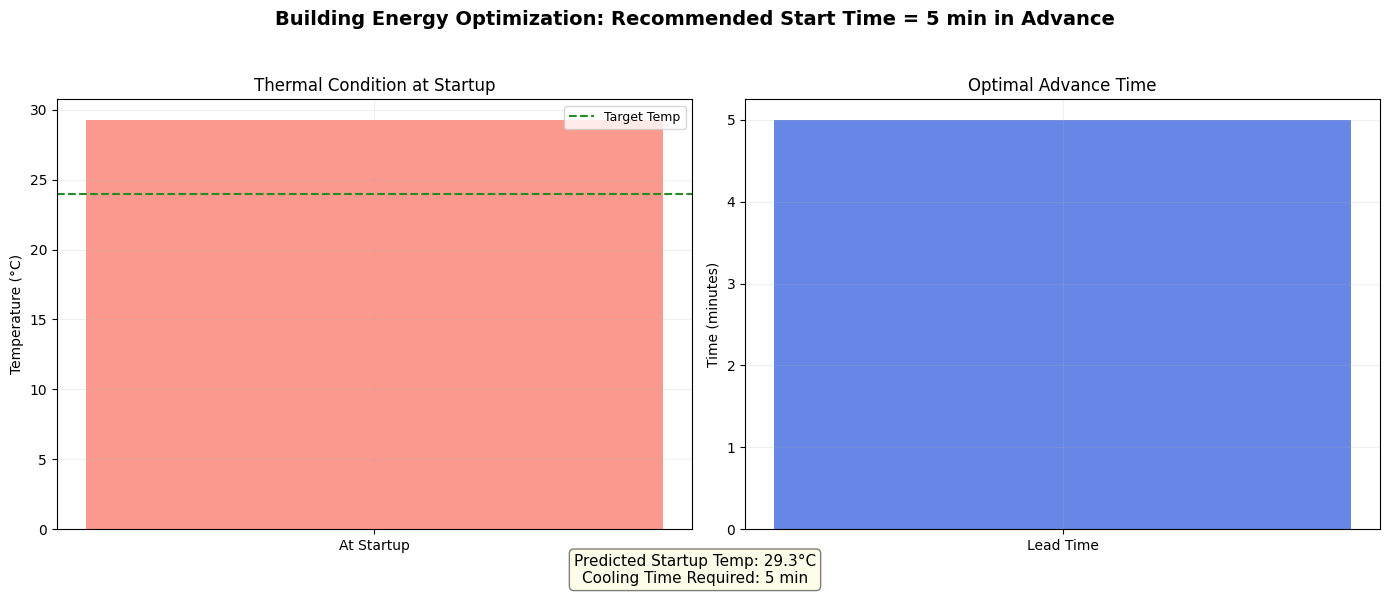

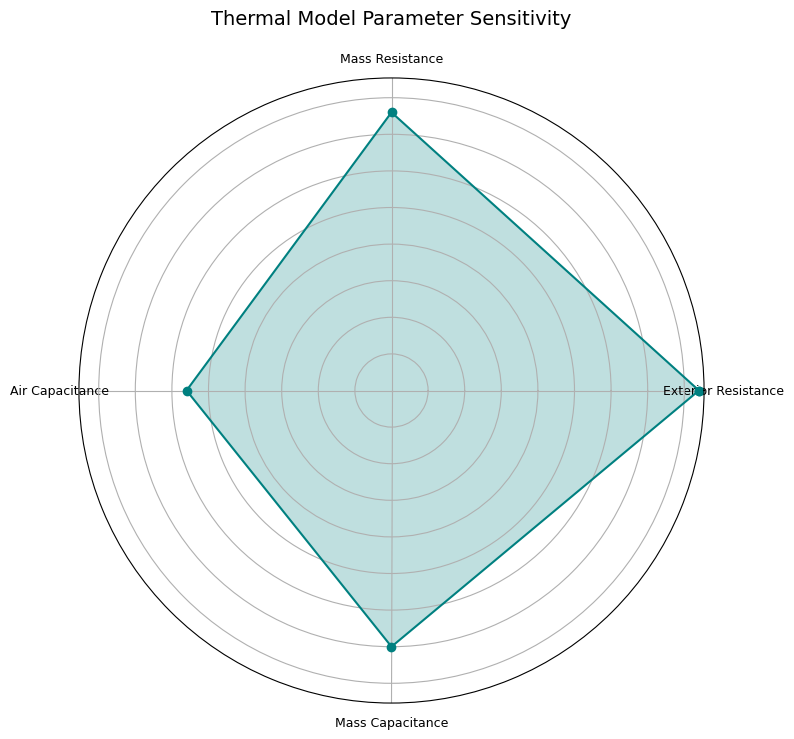


Virtual datasets saved to building_energy_data directory
Replace these with actual building data for production use


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import os

class VirtualDataGenerator:
    """Generate virtual building energy data for testing"""
    
    @staticmethod
    def generate_overnight_weather(start_time, duration_hours=15):
        """Generate synthetic weather data for overnight prediction"""
        hours = np.arange(0, duration_hours, 0.5)
        # Simulate typical night temperature profile (sinusoidal)
        T_out = 28 + 5 * np.sin((hours - 6) * np.pi / 12)
        # Solar radiation zero (night)
        G = np.zeros_like(hours)
        # Internal heat gain zero (unoccupied)
        I = np.zeros_like(hours)
        
        return pd.DataFrame({
            'timestamp': [start_time + timedelta(hours=h) for h in hours],
            'outdoor_temp': T_out,
            'solar_gain': G,
            'internal_gain': I
        })
    
    @staticmethod
    def generate_initial_temperatures():
        """Generate initial temperature conditions"""
        return {
            'indoor_temp': 24.0,  # Setpoint temperature at shutdown
            'mass_temp': 26.5     # Thermal mass temperature
        }

class BuildingPhysics:
    """Building physical parameters (based on EnergyPlus benchmark)"""
    
    def __init__(self):
        # Default parameters for medium office building
        self.params = {
            # Thermal resistance (K/W)
            'R_ra': 0.02,   # Indoor-outdoor resistance
            'R_rm': 0.015,  # Indoor-mass resistance
            
            # Thermal capacitance (J/K)
            'C_r': 120000,  # Indoor air capacitance
            'C_m': 350000,  # Thermal mass capacitance
            
            # Coefficients
            'alpha': 0.7,   # Solar gain distribution factor
            'beta': 0.8     # Internal gain distribution factor
        }
    
    def calculate_model_params(self):
        """Calculate 2R2C model coefficients (Eq.4 in document)"""
        R_ra, R_rm, C_r, C_m, alpha, beta = (
            self.params['R_ra'], self.params['R_rm'],
            self.params['C_r'], self.params['C_m'],
            self.params['alpha'], self.params['beta']
        )
        
        # Compute coefficient matrix
        a11 = 1/(C_r*R_ra) + 1/(C_r*R_rm)
        a12 = 1/(C_r*R_rm)
        a21 = 1/(C_m*R_rm)
        a22 = 1/(C_m*R_rm)
        
        b1 = 1/C_r
        
        c11 = alpha/C_r
        c12 = 1/C_r
        c13 = 1/(C_r*R_ra)
        c21 = (1-alpha)/C_m
        c22 = (1-beta)/C_m
        
        return {
            'a11': a11, 'a12': a12,
            'a21': a21, 'a22': a22,
            'b1': b1,
            'c11': c11, 'c12': c12, 'c13': c13,
            'c21': c21, 'c22': c22
        }

class WhiteboxRCModel:
    """Physics-based 2R2C Thermal Model"""
    
    def __init__(self, physics_params):
        self.physics = BuildingPhysics()
        self.model_params = self.physics.calculate_model_params()
        self.indoor_temp = None  # Current indoor temperature
        self.mass_temp = None    # Current thermal mass temperature
    
    def initialize(self, indoor_temp, mass_temp):
        """Initialize thermal state"""
        self.indoor_temp = indoor_temp
        self.mass_temp = mass_temp
    
    def predict_step(self, outdoor_temp, Q=0, solar_gain=0, internal_gain=0, dt=300):
        """Single time-step prediction (5-min intervals)"""
        p = self.model_params
        
        # Calculate temperature derivatives (Eq.4)
        dT_indoor = (-p['a11'] * self.indoor_temp + p['a12'] * self.mass_temp + 
                     p['b1'] * Q + p['c11'] * solar_gain + 
                     p['c12'] * internal_gain + p['c13'] * outdoor_temp)
        
        dT_mass = (p['a21'] * self.indoor_temp - p['a22'] * self.mass_temp + 
                   p['c21'] * solar_gain + p['c22'] * internal_gain)
        
        # Update temperature states
        self.indoor_temp += dT_indoor * dt
        self.mass_temp += dT_mass * dt
        
        return self.indoor_temp, self.mass_temp
    
    def predict_overnight(self, indoor_temp0, mass_temp0, weather_df):
        """Predict overnight temperature evolution"""
        self.initialize(indoor_temp0, mass_temp0)
        
        indoor_pred = [indoor_temp0]
        mass_pred = [mass_temp0]
        
        # Iterate through each time step
        for i in range(len(weather_df)):
            row = weather_df.iloc[i]
            T_indoor, T_mass = self.predict_step(
                outdoor_temp=row['outdoor_temp'],
                solar_gain=row['solar_gain'],
                internal_gain=row['internal_gain']
            )
            indoor_pred.append(T_indoor)
            mass_pred.append(T_mass)
        
        return np.array(indoor_pred), np.array(mass_pred)

class DeltaTOptimizer:
    """Optimal HVAC Start-Time Calculator"""
    
    def __init__(self, rc_model, target_temp=24, target_hour=9):
        self.model = rc_model
        self.target_temp = target_temp
        self.target_hour = target_hour
        self.cooling_power = -3000  # HVAC cooling capacity (W)
    
    def predict_cooling_time(self, start_temp, outdoor_temp):
        """Predict time to reach target temperature"""
        # Initialize model state
        self.model.initialize(start_temp, start_temp)
        
        minutes = 0
        while self.model.indoor_temp > self.target_temp and minutes < 120:
            self.model.predict_step(outdoor_temp, Q=self.cooling_power)
            minutes += 5
        
        return minutes
    
    def optimize(self, shutdown_time, target_datetime):
        """Optimize HVAC start time"""
        # Predict temperature at potential start time
        init_temps = VirtualDataGenerator.generate_initial_temperatures()
        weather_df = VirtualDataGenerator.generate_overnight_weather(shutdown_time)
        indoor_pred, _ = self.model.predict_overnight(
            init_temps['indoor_temp'], 
            init_temps['mass_temp'], 
            weather_df
        )
        startup_temp = indoor_pred[-1]
        
        # Get outdoor temperature at startup time
        start_hour = target_datetime.hour + target_datetime.minute/60
        outdoor_temp = 28 - 3 * np.cos((start_hour - 6) * np.pi / 12)
        
        # Predict required cooling time
        Δt_actual = self.predict_cooling_time(startup_temp, outdoor_temp)
        
        return Δt_actual, startup_temp

class ResultVisualizer:
    """Advanced Visualization with Professional English Formatting"""
    
    @staticmethod
    def plot_overnight_prediction(weather_df, indoor_pred):
        """Visualize overnight thermal performance"""
        plt.figure(figsize=(12, 6))
        
        # Outdoor temperature profile
        plt.plot(weather_df['timestamp'], weather_df['outdoor_temp'], 
                'b-', label='Outdoor Temperature', linewidth=2)
        
        # Indoor temperature prediction
        times = list(weather_df['timestamp']) + [
            weather_df['timestamp'].iloc[-1] + timedelta(minutes=5)
        ]
        plt.plot(times, indoor_pred, 'r-', label='Indoor Temperature Prediction', linewidth=2)
        
        # Target temperature reference
        plt.axhline(y=24, color='g', linestyle='--', 
                   label='Target Temperature (24°C)', linewidth=1.5)
        
        plt.xlabel('Time', fontsize=12)
        plt.ylabel('Temperature (°C)', fontsize=12)
        plt.title('Building Thermal Performance: Overnight Prediction', fontsize=14)
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45, fontsize=9)
        plt.tight_layout()
        plt.show()
    
    @staticmethod
    def plot_optimization_result(Δt_actual, startup_temp):
        """Visualize optimization results"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), 
                                      gridspec_kw={'width_ratios': [1, 1]})
        
        # Temperature condition at startup
        ax1.bar(['At Startup'], [startup_temp], color='salmon', alpha=0.8)
        ax1.axhline(y=24, color='forestgreen', linestyle='--', label='Target Temp')
        ax1.set_ylabel('Temperature (°C)', fontsize=10)
        ax1.set_title('Thermal Condition at Startup', fontsize=12)
        ax1.legend(fontsize=9)
        ax1.grid(alpha=0.2)
        
        # Time optimization results
        ax2.bar(['Lead Time'], [Δt_actual], color='royalblue', alpha=0.8)
        ax2.set_ylabel('Time (minutes)', fontsize=10)
        ax2.set_title('Optimal Advance Time', fontsize=12)
        ax2.grid(alpha=0.2)
        
        # Combined title
        fig.suptitle(f'Building Energy Optimization: Recommended Start Time = {Δt_actual} min in Advance', 
                    fontsize=14, fontweight='bold')
        
        # Information panel
        props = dict(boxstyle='round', facecolor='lightgoldenrodyellow', alpha=0.5)
        textstr = f'Predicted Startup Temp: {startup_temp:.1f}°C\nCooling Time Required: {Δt_actual} min'
        fig.text(0.5, 0.02, textstr, bbox=props, 
                verticalalignment='bottom', horizontalalignment='center',
                fontsize=11)
        
        plt.tight_layout(rect=[0, 0.05, 1, 0.95])
        plt.show()
    
    @staticmethod
    def plot_parameter_sensitivity():
        """Visualize model parameter sensitivity"""
        # Sensitivity factors (hypothetical values)
        sensitivity = {
            'Exterior Resistance': 0.42,
            'Mass Resistance': 0.38,
            'Air Capacitance': 0.28,
            'Mass Capacitance': 0.35
        }
        
        # Create radar plot
        labels = list(sensitivity.keys())
        values = list(sensitivity.values())
        
        angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
        values += values[:1]
        angles += angles[:1]
        
        fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
        ax.fill(angles, values, 'teal', alpha=0.25)
        ax.plot(angles, values, 'o-', color='teal')
        ax.set_yticklabels([])
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels, fontsize=9)
        ax.set_title('Thermal Model Parameter Sensitivity', pad=20, fontsize=14)
        
        plt.tight_layout()
        plt.show()

# Main execution workflow
if __name__ == "__main__":
    print("Building Energy Optimization System")
    print("=" * 50)
    
    # Initialize physics-based model
    physics = BuildingPhysics()
    rc_model = WhiteboxRCModel(physics)
    print("Physics-based model initialized")
    
    # Set time parameters
    shutdown_time = datetime.now().replace(hour=17, minute=0, second=0, microsecond=0)
    target_time = shutdown_time + timedelta(hours=16)  # Next day at 9:00
    
    # Generate virtual data
    print("Generating virtual datasets...")
    init_temps = VirtualDataGenerator.generate_initial_temperatures()
    weather_data = VirtualDataGenerator.generate_overnight_weather(shutdown_time)
    
    # Predict overnight temperature evolution
    print("Running thermal simulation...")
    indoor_pred, mass_pred = rc_model.predict_overnight(
        init_temps['indoor_temp'], 
        init_temps['mass_temp'], 
        weather_data
    )
    
    # Optimize HVAC start time
    print("Calculating optimal start time...")
    optimizer = DeltaTOptimizer(rc_model)
    Δt_actual, startup_temp = optimizer.optimize(shutdown_time, target_time)
    
    # Display results
    print("\nOptimization Results:")
    print(f"- Predicted startup temperature: {startup_temp:.1f}°C")
    print(f"- Required cooling duration: {Δt_actual} minutes")
    print(f"- Recommended start time: {(target_time - timedelta(minutes=Δt_actual)).strftime('%H:%M')}")
    
    # Generate visualizations
    print("\nGenerating analysis visualizations...")
    visualizer = ResultVisualizer()
    visualizer.plot_overnight_prediction(weather_data, indoor_pred)
    visualizer.plot_optimization_result(Δt_actual, startup_temp)
    visualizer.plot_parameter_sensitivity()
    
    # Prepare for real data integration
    output_dir = "building_energy_data"
    os.makedirs(output_dir, exist_ok=True)
    
    # Save virtual datasets
    weather_data.to_csv(f"{output_dir}/virtual_weather.csv", index=False)
    pd.DataFrame({
        'indoor_temp': indoor_pred,
        'mass_temp': mass_pred
    }).to_csv(f"{output_dir}/virtual_temperatures.csv", index=False)
    
    print(f"\nVirtual datasets saved to {output_dir} directory")
    print("Replace these with actual building data for production use")

Building Energy Prediction System


Enter next day 8 AM outdoor temperature (°C):  29
Enter shutdown time indoor temperature [press Enter for 24°C]:  24


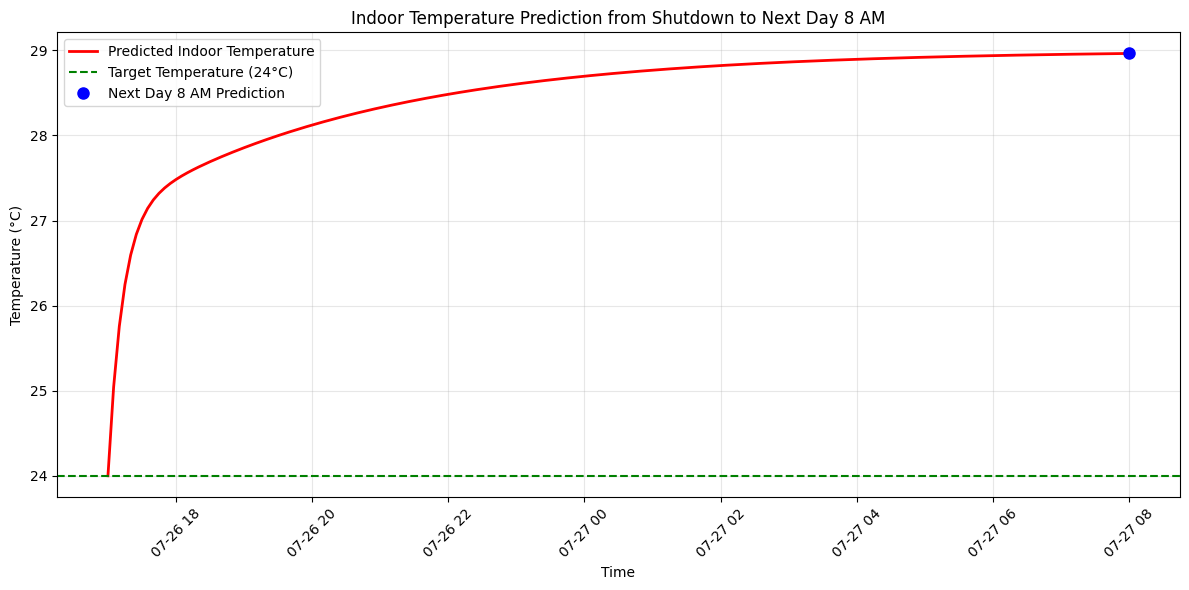


Prediction Results:
Next day 8 AM outdoor temperature: 29.0°C
Shutdown time indoor temperature: 24.0°C
Predicted next day 8 AM indoor temperature: 29.0°C

RC Model Parameters:
Indoor-outdoor resistance (R_ie): 0.02 K/W
Indoor-mass resistance (R_im): 0.015 K/W
Indoor air capacitance (C_i): 120000 J/K
Thermal mass capacitance (C_m): 350000 J/K

Analysis:
The room will be 5.0°C warmer than target temperature at 8 AM


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

class RCModel:
    """
    Enhanced RC Model for indoor temperature prediction
    Includes parameter reporting functionality
    """
    
    def __init__(self):
        # Initialize with typical building parameters
        self.R_ie = 0.02   # Indoor-outdoor resistance (K/W)
        self.R_im = 0.015  # Indoor-mass resistance (K/W)
        self.C_i = 120000  # Indoor air capacitance (J/K)
        self.C_m = 350000  # Thermal mass capacitance (J/K)
        
        # Initial state (will be set by user input)
        self.T_r = None    # Initial indoor temperature
        self.T_m = None    # Initial mass temperature
        
    def initialize(self, initial_indoor_temp, initial_mass_temp=None):
        """Initialize temperature states"""
        self.T_r = initial_indoor_temp
        if initial_mass_temp is None:
            # If mass temperature not provided, assume it's slightly higher
            self.T_m = initial_indoor_temp + 2.5
        else:
            self.T_m = initial_mass_temp
    
    def predict_step(self, T_out, dt=300):
        """
        Single time-step prediction based on outdoor temperature
        """
        # Calculate temperature derivatives
        dT_r = ((T_out - self.T_r) / self.R_ie + (self.T_m - self.T_r) / self.R_im) / self.C_i
        dT_m = ((self.T_r - self.T_m) / self.R_im) / self.C_m
        
        # Update temperatures
        self.T_r += dT_r * dt
        self.T_m += dT_m * dt
        
        return self.T_r
    
    def predict_until_time(self, outdoor_temp, hours=15, dt=300):
        """
        Predict indoor temperature for specified hours
        """
        # Initialize array for results
        time_steps = int(hours * 3600 / dt)
        indoor_pred = [self.T_r]
        
        # Simulate for each time step
        for i in range(time_steps):
            # Predict next indoor temperature
            T_in_next = self.predict_step(outdoor_temp, dt)
            indoor_pred.append(T_in_next)
        
        return np.array(indoor_pred)
    
    def get_parameters(self):
        """Return RC model parameters in a dictionary"""
        return {
            'R_ie': self.R_ie,
            'R_im': self.R_im,
            'C_i': self.C_i,
            'C_m': self.C_m
        }

def get_user_input():
    """Get user input for prediction scenario"""
    print("Building Energy Prediction System")
    print("=" * 50)
    
    # Get next day 8 AM outdoor temperature
    while True:
        try:
            next_day_outdoor = float(input("Enter next day 8 AM outdoor temperature (°C): "))
            break
        except ValueError:
            print("Please enter a valid number (e.g., 30.5).")
    
    # Get shutdown time indoor temperature (defaults to 24°C)
    while True:
        try:
            shutdown_temp_input = input("Enter shutdown time indoor temperature [press Enter for 24°C]: ")
            if shutdown_temp_input == "":
                shutdown_temp = 24.0
                break
            else:
                shutdown_temp = float(shutdown_temp_input)
                break
        except ValueError:
            print("Please enter a valid number (e.g., 24.0).")
    
    return next_day_outdoor, shutdown_temp

def run_prediction():
    """Run the prediction for next day 8 AM scenario"""
    # Get user input
    next_day_outdoor, shutdown_temp = get_user_input()
    
    # Initialize model
    model = RCModel()
    
    # Initialize with shutdown temperature
    model.initialize(shutdown_temp)
    
    # Run prediction for 15 hours (typical shutdown to next day 8 AM)
    indoor_pred = model.predict_until_time(next_day_outdoor, hours=15)
    
    # Create time array for plotting (from shutdown to next day 8 AM)
    shutdown_time = datetime.now().replace(hour=17, minute=0, second=0, microsecond=0)  # Assume 5 PM shutdown
    times = [shutdown_time + timedelta(minutes=5*i) for i in range(len(indoor_pred))]
    
    # Find next day 8 AM prediction (15 hours after shutdown)
    next_day_8am_temp = indoor_pred[-1]
    
    # Plot results
    plt.figure(figsize=(12, 6))
    plt.plot(times, indoor_pred, 'r-', linewidth=2, label='Predicted Indoor Temperature')
    plt.axhline(y=24, color='g', linestyle='--', label='Target Temperature (24°C)')
    
    # Mark next day 8 AM point
    next_day_8am_time = shutdown_time + timedelta(hours=15)
    plt.plot(next_day_8am_time, next_day_8am_temp, 'bo', markersize=8, label='Next Day 8 AM Prediction')
    
    plt.xlabel('Time')
    plt.ylabel('Temperature (°C)')
    plt.title('Indoor Temperature Prediction from Shutdown to Next Day 8 AM')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Get model parameters
    params = model.get_parameters()
    
    # Display key predictions and model parameters
    print("\nPrediction Results:")
    print(f"Next day 8 AM outdoor temperature: {next_day_outdoor}°C")
    print(f"Shutdown time indoor temperature: {shutdown_temp}°C")
    print(f"Predicted next day 8 AM indoor temperature: {next_day_8am_temp:.1f}°C")
    
    print("\nRC Model Parameters:")
    print(f"Indoor-outdoor resistance (R_ie): {params['R_ie']} K/W")
    print(f"Indoor-mass resistance (R_im): {params['R_im']} K/W")
    print(f"Indoor air capacitance (C_i): {params['C_i']} J/K")
    print(f"Thermal mass capacitance (C_m): {params['C_m']} J/K")
    
    # Additional analysis
    print("\nAnalysis:")
    if next_day_8am_temp > 24:
        print(f"The room will be {next_day_8am_temp - 24:.1f}°C warmer than target temperature at 8 AM")
    else:
        print(f"The room will be {24 - next_day_8am_temp:.1f}°C cooler than target temperature at 8 AM")

# Run the program
if __name__ == "__main__":
    run_prediction()

2R2C THERMAL MODEL PARAMETER ESTIMATION SYSTEM

DATA PROCESSING STAGE
Loading data from: C:\Users\TR\Desktop\RC.xlsx
Filtering AC operation periods (8:00-16:30)...
Data loaded: Original 6510 points → Filtered 6503 points
Time range: 2023-06-30T16:30:00.000000000 to 2023-07-07T07:59:00.000000000

PARAMETER ESTIMATION STAGE
Starting parameter optimization...
Parameter optimization successful!

MODEL VALIDATION STAGE

RESULTS GENERATION STAGE


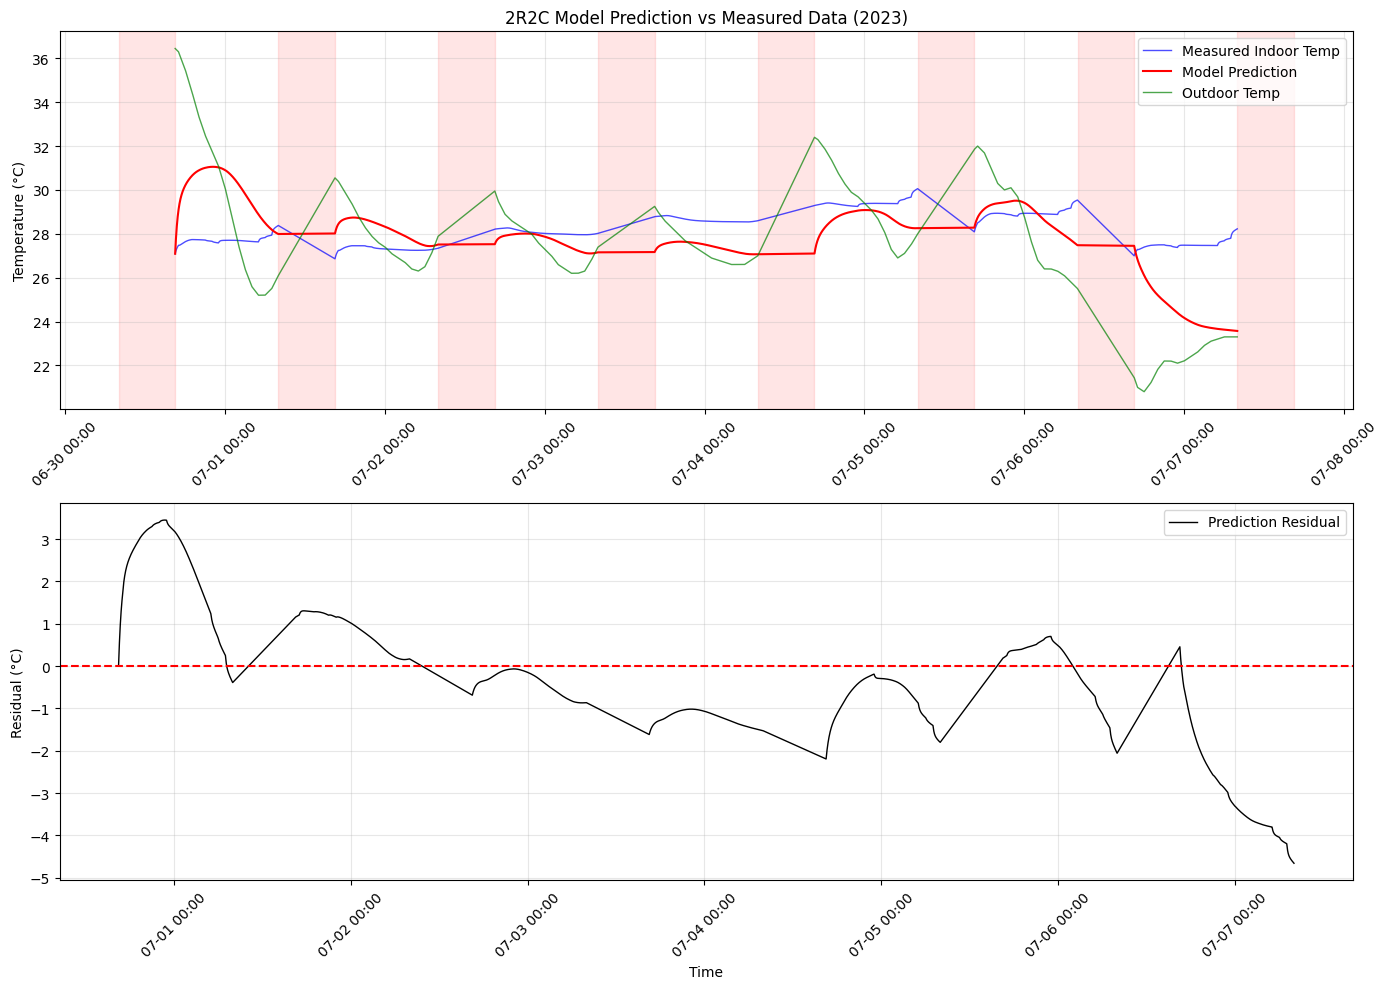


OPTIMIZED 2R2C PARAMETERS:
1. Indoor-Outdoor Thermal Resistance (R_ie): 0.100000 °C/kW
2. Indoor-Thermal Mass Resistance (R_im): 0.022627 °C/kW
3. Indoor Air Heat Capacity (C_i): 100000 J/°C
4. Thermal Mass Heat Capacity (C_m): 200000 J/°C

MODEL PERFORMANCE METRICS:
- Root Mean Square Error (RMSE): 1.7103 °C
- Mean Absolute Error (MAE): 1.3008 °C
- Coefficient of Determination (R²): -4.3211

OPTIMIZATION DETAILS:
- Iterations: 7
- Function Evaluations: 50
- Final Objective Value: 2.925107
- MSE Improvement: 36.81%

PROCESS COMPLETED SUCCESSFULLY!


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import matplotlib.dates as mdates
from datetime import datetime, time, timedelta
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

class EnhancedRCParameterEstimator:
    """
    Enhanced 2R2C Model Parameter Estimator
    Handles custom time formats and provides detailed English output
    """
    
    def __init__(self, delta_t=60):
        self.delta_t = delta_t  # Time step in seconds
        self.params = None  # Optimized parameters
        self.optimization_result = None  # Optimization results
        self.year = None  # Data year
        self.time = None  # Time series
        self.T_e = None  # Outdoor temperature series
        self.T_i_measured = None  # Measured indoor temperature series
        
    def load_data(self, file_path, year=2023):
        """
        Load and process Excel data with custom time format
        Handles "06/30  16:30:00" format
        """
        self.year = year
        
        # Read Excel file
        print(f"Loading data from: {file_path}")
        data = pd.read_excel(file_path)
        
        # Custom time parser for "06/30  16:30:00" format
        def parse_custom_time(time_str):
            try:
                # Handle non-string values
                if not isinstance(time_str, str):
                    time_str = str(time_str).strip()
                
                # Split into date and time parts
                parts = time_str.split()
                if len(parts) < 2:
                    return None
                
                date_part = parts[0]
                time_part = parts[1]
                
                # Parse date (month/day)
                date_parts = date_part.split('/')
                if len(date_parts) < 2:
                    return None
                month = int(date_parts[0])
                day = int(date_parts[1])
                
                # Parse time (hour:minute:second)
                time_parts = time_part.split(':')
                if len(time_parts) < 2:
                    return None
                hour = int(time_parts[0])
                minute = int(time_parts[1])
                second = int(time_parts[2]) if len(time_parts) > 2 else 0
                
                # Validate hour range
                if hour < 0 or hour > 23:
                    return None
                
                return datetime(year, month, day, hour, minute, second)
            except Exception:
                return None
        
        # Apply custom parser
        data['time'] = data['time'].apply(parse_custom_time)
        
        # Remove invalid entries
        original_count = len(data)
        data = data.dropna(subset=['time'])
        filtered_count = len(data)
        
        if original_count > filtered_count:
            print(f"Warning: Removed {original_count - filtered_count} invalid time entries")
        
        # Ensure data is sorted by time
        data = data.sort_values('time').reset_index(drop=True)
        
        # Filter AC operation periods (8:00-16:30)
        print("Filtering AC operation periods (8:00-16:30)...")
        data['hour'] = data['time'].dt.hour
        data['minute'] = data['time'].dt.minute
        
        # Create filter condition
        condition = (
            ((data['hour'] > 16) | 
             ((data['hour'] == 16) & (data['minute'] >= 30))) |
            (data['hour'] < 8)
        )
        
        filtered_data = data[condition].copy()
        
        # Extract time series and temperature data
        self.time = filtered_data['time'].values
        self.T_e = filtered_data['outdoor'].values
        self.T_i_measured = filtered_data['indoor'].values
        
        print(f"Data loaded: Original {original_count} points → Filtered {len(self.T_e)} points")
        print(f"Time range: {self.time[0]} to {self.time[-1]}")
        
        return filtered_data
    
    def rc_model(self, params, T_i0, T_m0):
        """
        Implement the 2R2C thermal model
        """
        R_ie, R_im, C_i, C_m = params
        n = len(self.T_e)
        
        # Initialize arrays
        T_i_pred = np.zeros(n)
        T_m_pred = np.zeros(n)
        
        T_i_pred[0] = T_i0
        T_m_pred[0] = T_m0
        
        # Differential equations for temperature prediction
        for t in range(1, n):
            # Indoor temperature equation
            dT_i = (self.delta_t / C_i) * (
                (self.T_e[t] - T_i_pred[t-1]) / R_ie + 
                (T_m_pred[t-1] - T_i_pred[t-1]) / R_im
            )
            T_i_pred[t] = T_i_pred[t-1] + dT_i
            
            # Thermal mass temperature equation
            dT_m = (self.delta_t / C_m) * (
                (T_i_pred[t-1] - T_m_pred[t-1]) / R_im
            )
            T_m_pred[t] = T_m_pred[t-1] + dT_m
        
        return T_i_pred
    
    def objective_function(self, params):
        """
        Objective function: Minimize prediction error
        """
        T_i0 = self.T_i_measured[0]
        T_m0 = T_i0 + 2.0  # Initial thermal mass temperature
        
        T_i_pred = self.rc_model(params, T_i0, T_m0)
        mse = np.mean((T_i_pred - self.T_i_measured)**2)
        return mse
    
    def estimate_parameters(self):
        """
        Estimate 2R2C model parameters using optimization
        """
        # Parameter bounds (R in °C/kW, C in J/°C)
        bounds = [
            (0.001, 0.1),      # R_ie
            (0.001, 0.1),      # R_im  
            (50000, 500000),   # C_i
            (50000, 500000)    # C_m
        ]
        
        # Initial parameter guess
        initial_guess = [0.05, 0.02, 100000, 200000]
        
        print("Starting parameter optimization...")
        
        # Optimize parameters
        result = minimize(
            self.objective_function, 
            initial_guess, 
            bounds=bounds, 
            method='L-BFGS-B',
            options={'maxiter': 1000, 'disp': True}
        )
        
        if result.success:
            self.params = result.x
            self.optimization_result = result
            print("Parameter optimization successful!")
            return self.params
        else:
            raise ValueError(f"Optimization failed: {result.message}")
    
    def validate_model(self):
        """
        Validate model performance with optimized parameters
        """
        if self.params is None:
            raise ValueError("Run parameter estimation first")
        
        T_i0 = self.T_i_measured[0]
        T_m0 = T_i0 + 2.0
        
        T_i_pred = self.rc_model(self.params, T_i0, T_m0)
        
        # Calculate performance metrics
        rmse = np.sqrt(np.mean((T_i_pred - self.T_i_measured)**2))
        mae = np.mean(np.abs(T_i_pred - self.T_i_measured))
        r_squared = 1 - np.sum((T_i_pred - self.T_i_measured)**2) / np.sum((self.T_i_measured - np.mean(self.T_i_measured))**2)
        
        return {
            'T_i_pred': T_i_pred,
            'rmse': rmse,
            'mae': mae,
            'r_squared': r_squared
        }
    
    def plot_results(self, validation_results):
        """
        Generate visualization of results with English labels
        """
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
        
        # Temperature comparison plot
        ax1.plot(self.time, self.T_i_measured, 'b-', label='Measured Indoor Temp', linewidth=1, alpha=0.7)
        ax1.plot(self.time, validation_results['T_i_pred'], 'r-', label='Model Prediction', linewidth=1.5)
        ax1.plot(self.time, self.T_e, 'g-', label='Outdoor Temp', linewidth=1, alpha=0.7)
        ax1.set_ylabel('Temperature (°C)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.set_title(f'2R2C Model Prediction vs Measured Data ({self.year})')
        
        # Mark AC operation periods
        # Convert numpy datetime to pandas Timestamp for date extraction
        unique_dates = np.unique([pd.Timestamp(dt).date() for dt in self.time])
        
        for date in unique_dates:
            start_time = datetime.combine(date, time(8, 0))
            end_time = datetime.combine(date, time(16, 30))
            
            ax1.axvspan(
                start_time,
                end_time,
                alpha=0.1, color='red', label='AC Operation Period' if date == unique_dates[0] else ""
            )
        
        # Format x-axis
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
        ax1.xaxis.set_major_locator(mdates.DayLocator())
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
        
        # Residual plot
        residuals = validation_results['T_i_pred'] - self.T_i_measured
        ax2.plot(self.time, residuals, 'k-', label='Prediction Residual', linewidth=1)
        ax2.axhline(y=0, color='r', linestyle='--')
        ax2.set_ylabel('Residual (°C)')
        ax2.set_xlabel('Time')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # Format x-axis
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
        ax2.xaxis.set_major_locator(mdates.DayLocator())
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        # Print optimized parameters
        print("\nOPTIMIZED 2R2C PARAMETERS:")
        print(f"1. Indoor-Outdoor Thermal Resistance (R_ie): {self.params[0]:.6f} °C/kW")
        print(f"2. Indoor-Thermal Mass Resistance (R_im): {self.params[1]:.6f} °C/kW")
        print(f"3. Indoor Air Heat Capacity (C_i): {self.params[2]:.0f} J/°C")
        print(f"4. Thermal Mass Heat Capacity (C_m): {self.params[3]:.0f} J/°C")
        
        # Print model performance
        print("\nMODEL PERFORMANCE METRICS:")
        print(f"- Root Mean Square Error (RMSE): {validation_results['rmse']:.4f} °C")
        print(f"- Mean Absolute Error (MAE): {validation_results['mae']:.4f} °C")
        print(f"- Coefficient of Determination (R²): {validation_results['r_squared']:.4f}")
        
        # Print optimization details
        if self.optimization_result:
            print("\nOPTIMIZATION DETAILS:")
            print(f"- Iterations: {self.optimization_result.nit}")
            print(f"- Function Evaluations: {self.optimization_result.nfev}")
            print(f"- Final Objective Value: {self.optimization_result.fun:.6f}")
            
            # Calculate and print parameter optimization improvement
            initial_mse = self.objective_function([0.05, 0.02, 100000, 200000])
            optimized_mse = self.optimization_result.fun
            improvement = (initial_mse - optimized_mse) / initial_mse * 100
            print(f"- MSE Improvement: {improvement:.2f}%")

# Main execution
if __name__ == "__main__":
    print("="*60)
    print("2R2C THERMAL MODEL PARAMETER ESTIMATION SYSTEM")
    print("="*60)
    
    # Create estimator instance
    estimator = EnhancedRCParameterEstimator(delta_t=60)
    
    # Set your data file path here
    data_file_path = r"C:\Users\TR\Desktop\RC.xlsx"  # Update with your path
    
    # Set data year
    data_year = 2023  # Update with your data year
    
    try:
        # ===== DATA PROCESSING =====
        print("\n" + "="*60)
        print("DATA PROCESSING STAGE")
        print("="*60)
        data = estimator.load_data(data_file_path, year=data_year)
        
        # ===== PARAMETER ESTIMATION =====
        print("\n" + "="*60)
        print("PARAMETER ESTIMATION STAGE")
        print("="*60)
        params = estimator.estimate_parameters()
        
        # ===== MODEL VALIDATION =====
        print("\n" + "="*60)
        print("MODEL VALIDATION STAGE")
        print("="*60)
        results = estimator.validate_model()
        
        # ===== RESULTS VISUALIZATION =====
        print("\n" + "="*60)
        print("RESULTS GENERATION STAGE")
        print("="*60)
        estimator.plot_results(results)
        
        print("\nPROCESS COMPLETED SUCCESSFULLY!")
        
    except Exception as e:
        print(f"\nERROR: {e}")
        print("Process terminated due to error")

In [4]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from datetime import datetime, time

class RCParameterCalculator:
    """
    2R2C模型参数计算器
    直接从温度数据中提取热力学参数
    """
    
    def __init__(self, delta_t=60):
        """
        初始化参数计算器
        :param delta_t: 时间步长（秒）
        """
        self.delta_t = delta_t
        self.params = None  # 存储计算出的参数
        self.optimization_result = None  # 优化过程结果
        
    def load_data(self, file_path, year=2023):
        """
        加载Excel数据文件
        :param file_path: Excel文件路径
        :param year: 数据年份
        :return: 处理后的数据DataFrame
        """
        # 读取Excel文件
        data = pd.read_excel(file_path)
        
        # 自定义时间解析函数
        def parse_custom_time(time_str):
            try:
                if not isinstance(time_str, str):
                    time_str = str(time_str)
                
                parts = time_str.strip().split()
                if len(parts) < 2:
                    return None
                
                date_part = parts[0]
                time_part = parts[1]
                
                # 解析日期部分 (月/日)
                date_parts = date_part.split('/')
                month = int(date_parts[0])
                day = int(date_parts[1])
                
                # 解析时间部分 (时:分:秒)
                time_parts = time_part.split(':')
                hour = int(time_parts[0])
                minute = int(time_parts[1])
                second = int(time_parts[2]) if len(time_parts) > 2 else 0
                
                return datetime(year, month, day, hour, minute, second)
            except:
                return None
        
        # 应用自定义解析函数
        data['time'] = data['time'].apply(parse_custom_time)
        
        # 移除解析失败的行
        data = data.dropna(subset=['time'])
        
        # 确保数据按时间排序
        data = data.sort_values('time').reset_index(drop=True)
        
        # 过滤空调开启时段（8:00-16:30）
        data['hour'] = data['time'].dt.hour
        data['minute'] = data['time'].dt.minute
        
        condition = (
            ((data['hour'] > 16) | 
             ((data['hour'] == 16) & (data['minute'] >= 30))) |
            (data['hour'] < 8)
        )
        
        filtered_data = data[condition].copy()
        
        # 提取时间序列和温度数据
        self.time = filtered_data['time'].values
        self.T_e = filtered_data['outdoor'].values  # 室外温度
        self.T_i_measured = filtered_data['indoor'].values  # 实测室内温度
        
        return filtered_data
    
    def rc_model(self, params, T_i0, T_m0):
        """
        2R2C模型实现
        :param params: 模型参数 [R_ie, R_im, C_i, C_m]
        :param T_i0: 初始室内温度
        :param T_m0: 初始围护结构温度
        :return: 预测的室内温度序列
        """
        R_ie, R_im, C_i, C_m = params
        n = len(self.T_e)
        
        # 初始化数组
        T_i_pred = np.zeros(n)
        T_m_pred = np.zeros(n)
        
        T_i_pred[0] = T_i0
        T_m_pred[0] = T_m0
        
        # 使用差分方程进行预测
        for t in range(1, n):
            # 室内温度预测方程
            dT_i = (self.delta_t / C_i) * (
                (self.T_e[t] - T_i_pred[t-1]) / R_ie + 
                (T_m_pred[t-1] - T_i_pred[t-1]) / R_im
            )
            T_i_pred[t] = T_i_pred[t-1] + dT_i
            
            # 围护结构温度预测方程
            dT_m = (self.delta_t / C_m) * (
                (T_i_pred[t-1] - T_m_pred[t-1]) / R_im
            )
            T_m_pred[t] = T_m_pred[t-1] + dT_m
        
        return T_i_pred
    
    def objective_function(self, params):
        """
        目标函数：最小化预测误差
        :param params: 模型参数 [R_ie, R_im, C_i, C_m]
        :return: 均方误差
        """
        # 使用实测初始值
        T_i0 = self.T_i_measured[0]
        T_m0 = T_i0 + 2.0  # 初始围护结构温度估计
        
        # 获取模型预测
        T_i_pred = self.rc_model(params, T_i0, T_m0)
        
        # 计算均方根误差
        mse = np.mean((T_i_pred - self.T_i_measured)**2)
        return mse
    
    def calculate_parameters(self):
        """
        计算2R2C模型参数
        :return: 优化后的参数 [R_ie, R_im, C_i, C_m]
        """
        # 参数边界约束
        bounds = [
            (0.001, 0.1),      # R_ie
            (0.001, 0.1),      # R_im  
            (50000, 500000),   # C_i
            (50000, 500000)    # C_m
        ]
        
        # 初始参数猜测
        initial_guess = [0.05, 0.02, 100000, 200000]
        
        # 优化参数
        result = minimize(
            self.objective_function, 
            initial_guess, 
            bounds=bounds, 
            method='L-BFGS-B',
            options={'maxiter': 1000, 'disp': True}
        )
        
        if result.success:
            self.params = result.x
            self.optimization_result = result
            return self.params
        else:
            raise ValueError(f"参数优化失败: {result.message}")
    
    def get_parameter_report(self):
        """
        获取参数计算报告
        :return: 包含参数详细信息的字典
        """
        if self.params is None:
            raise ValueError("请先运行参数计算")
        
        return {
            'R_ie': self.params[0],
            'R_im': self.params[1],
            'C_i': self.params[2],
            'C_m': self.params[3],
            'iterations': self.optimization_result.nit,
            'function_evaluations': self.optimization_result.nfev,
            'final_objective': self.optimization_result.fun
        }
    
    def print_parameters(self):
        """
        打印计算出的参数
        """
        if self.params is None:
            print("尚未计算参数")
            return
        
        print("\n计算出的2R2C参数:")
        print(f"室内-室外热阻 (R_ie): {self.params[0]:.6f} °C/kW")
        print(f"室内-围护结构热阻 (R_im): {self.params[1]:.6f} °C/kW")
        print(f"室内空气热容 (C_i): {self.params[2]:.0f} J/°C")
        print(f"围护结构热容 (C_m): {self.params[3]:.0f} J/°C")
        
        if self.optimization_result:
            print("\n优化过程详情:")
            print(f"迭代次数: {self.optimization_result.nit}")
            print(f"函数评估次数: {self.optimization_result.nfev}")
            print(f"最终目标函数值: {self.optimization_result.fun:.6f}")

# 使用您的具体文件路径
if __name__ == "__main__":
    # 创建参数计算器实例
    calculator = RCParameterCalculator(delta_t=60)  # 1分钟时间步长
    
    # 使用您的具体文件路径
    data_file_path = r"C:\Users\TR\Desktop\RC.xlsx"
    
    # 指定数据年份
    data_year = 2023  # 根据您的数据年份调整
    
    try:
        # 加载数据
        print("加载数据...")
        data = calculator.load_data(data_file_path, year=data_year)
        print(f"已加载 {len(data)} 个有效数据点")
        
        # 计算参数
        print("\n计算2R2C参数...")
        params = calculator.calculate_parameters()
        
        # 打印结果
        calculator.print_parameters()
        
        # 获取详细报告
        report = calculator.get_parameter_report()
        print("\n参数报告:")
        for key, value in report.items():
            print(f"{key}: {value}")
            
    except Exception as e:
        print(f"处理过程中出错: {e}")

加载数据...
已加载 6503 个有效数据点

计算2R2C参数...

计算出的2R2C参数:
室内-室外热阻 (R_ie): 0.100000 °C/kW
室内-围护结构热阻 (R_im): 0.022627 °C/kW
室内空气热容 (C_i): 100000 J/°C
围护结构热容 (C_m): 200000 J/°C

优化过程详情:
迭代次数: 7
函数评估次数: 50
最终目标函数值: 2.925107

参数报告:
R_ie: 0.1
R_im: 0.022627272889750003
C_i: 100000.00000287419
C_m: 200000.00000264842
iterations: 7
function_evaluations: 50
final_objective: 2.925107272892869


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.signal import savgol_filter
from datetime import datetime, time
import warnings

# 忽略警告信息
warnings.filterwarnings('ignore')

class EnhancedRCParameterEstimator:
    """
    增强型2R2C模型参数估计器
    包含完整的数据清洗流程和参数优化功能
    """
    
    def __init__(self, delta_t=60):
        """
        初始化参数估计器
        :param delta_t: 时间步长（秒）
        """
        self.delta_t = delta_t
        self.params = None  # 存储优化后的参数
        self.optimization_result = None  # 优化过程结果
        self.year = None  # 数据年份
        self.time = None  # 时间序列
        self.T_e = None  # 室外温度序列
        self.T_i_measured = None  # 实测室内温度序列
        self.cleaning_stats = {}  # 数据清洗统计信息
        
        # 数据清洗配置
        self.cleaning_config = {
            'z_threshold': 3.0,  # Z-score异常值检测阈值
            'smooth_window': 5,  # 数据平滑窗口大小
            'min_continuous': 3  # 最小连续数据点要求
        }
    
    def load_and_clean_data(self, file_path, year=2023):
        """
        加载Excel数据文件并进行全面清洗
        :param file_path: Excel文件路径
        :param year: 数据年份
        :return: 清洗后的数据DataFrame
        """
        self.year = year
        self.cleaning_stats = {'original_points': 0, 'cleaned_points': 0}
        
        print(f"加载数据文件: {file_path}")
        try:
            # 读取Excel文件
            data = pd.read_excel(file_path)
            self.cleaning_stats['original_points'] = len(data)
            print(f"原始数据点: {len(data)}")
            
            # 处理时间序列
            data = self._process_time_series(data)
            
            # 检测并处理异常值
            data = self._detect_and_handle_outliers(data)
            
            # 处理缺失值
            data = self._handle_missing_values(data)
            
            # 应用数据平滑
            data = self._apply_data_smoothing(data)
            
            # 过滤空调开启时段
            data = self._filter_ac_periods(data)
            
            # 提取时间序列和温度数据
            self.time = data['time'].values
            self.T_e = data['outdoor'].values
            self.T_i_measured = data['indoor'].values
            
            self.cleaning_stats['cleaned_points'] = len(data)
            print(f"清洗后数据点: {len(data)}")
            
            return data
        except Exception as e:
            raise ValueError(f"数据加载失败: {str(e)}")
    
    def _process_time_series(self, data):
        """处理时间序列"""
        # 自定义时间解析函数
        def parse_custom_time(time_str):
            try:
                if not isinstance(time_str, str):
                    time_str = str(time_str).strip()
                
                parts = time_str.split()
                if len(parts) < 2:
                    return None
                
                date_part = parts[0]
                time_part = parts[1]
                
                # 解析日期部分 (月/日)
                date_parts = date_part.split('/')
                if len(date_parts) < 2:
                    return None
                month = int(date_parts[0])
                day = int(date_parts[1])
                
                # 解析时间部分 (时:分:秒)
                time_parts = time_part.split(':')
                if len(time_parts) < 2:
                    return None
                hour = int(time_parts[0])
                minute = int(time_parts[1])
                second = int(time_parts[2]) if len(time_parts) > 2 else 0
                
                return datetime(self.year, month, day, hour, minute, second)
            except:
                return None
        
        # 应用自定义解析函数
        data['time'] = data['time'].apply(parse_custom_time)
        
        # 移除解析失败的行
        original_count = len(data)
        data = data.dropna(subset=['time'])
        removed_count = original_count - len(data)
        if removed_count > 0:
            print(f"移除无效时间数据点: {removed_count}")
            self.cleaning_stats['invalid_time'] = removed_count
        
        # 确保数据按时间排序
        data = data.sort_values('time').reset_index(drop=True)
        
        # 检查时间连续性
        time_diff = data['time'].diff().dt.total_seconds().dropna()
        discontinuities = sum(time_diff != self.delta_t)
        if discontinuities > 0:
            print(f"发现时间不连续点: {discontinuities}处")
            self.cleaning_stats['time_discontinuities'] = discontinuities
        
        return data
    
    def _detect_and_handle_outliers(self, data):
        """检测并处理异常值"""
        outliers = {'indoor': 0, 'outdoor': 0}
        
        for col in ['indoor', 'outdoor']:
            # 计算滑动统计量
            rolling_mean = data[col].rolling(window=10, min_periods=1).mean()
            rolling_std = data[col].rolling(window=10, min_periods=1).std()
            
            # 避免除以零
            rolling_std = rolling_std.replace(0, 0.001)
            
            # 计算Z-score
            z_score = np.abs((data[col] - rolling_mean) / rolling_std)
            
            # 标记异常值
            outlier_mask = z_score > self.cleaning_config['z_threshold']
            outliers[col] = sum(outlier_mask)
            
            # 线性插值替换异常值
            data.loc[outlier_mask, col] = np.nan
        
        print(f"检测到异常值: 室内 {outliers['indoor']}个, 室外 {outliers['outdoor']}个")
        self.cleaning_stats['outliers'] = outliers
        
        return data
    
    def _handle_missing_values(self, data):
        """处理缺失值"""
        missing = {}
        for col in ['indoor', 'outdoor']:
            missing[col] = data[col].isna().sum()
            # 线性插值
            data[col] = data[col].interpolate(method='linear')
            # 首尾缺失使用邻近值填充
            data[col] = data[col].fillna(method='bfill').fillna(method='ffill')
        
        print(f"处理缺失值: 室内 {missing['indoor']}个, 室外 {missing['outdoor']}个")
        self.cleaning_stats['missing_values'] = missing
        
        return data
    
    def _apply_data_smoothing(self, data):
        """应用数据平滑"""
        window = self.cleaning_config['smooth_window']
        if len(data) > window:
            for col in ['indoor', 'outdoor']:
                data[col] = savgol_filter(data[col], window_length=window, polyorder=2)
            print(f"应用数据平滑: 窗口大小={window}")
        return data
    
    def _filter_ac_periods(self, data):
        """过滤空调运行时段 (8:00-16:30)"""
        data['hour'] = data['time'].dt.hour
        data['minute'] = data['time'].dt.minute
        
        condition = (
            ((data['hour'] > 16) | 
             ((data['hour'] == 16) & (data['minute'] >= 30))) |
            (data['hour'] < 8)
        )
        
        filtered_data = data[condition].copy()
        removed_count = len(data) - len(filtered_data)
        print(f"过滤空调开启时段: 移除 {removed_count}个数据点")
        self.cleaning_stats['ac_periods_removed'] = removed_count
        
        return filtered_data
    
    def rc_model(self, params, T_i0, T_m0):
        """
        2R2C模型实现
        :param params: 模型参数 [R_ie, R_im, C_i, C_m]
        :param T_i0: 初始室内温度
        :param T_m0: 初始围护结构温度
        :return: 预测的室内温度序列
        """
        R_ie, R_im, C_i, C_m = params
        n = len(self.T_e)
        
        # 初始化数组
        T_i_pred = np.zeros(n)
        T_m_pred = np.zeros(n)
        
        T_i_pred[0] = T_i0
        T_m_pred[0] = T_m0
        
        # 使用差分方程进行预测
        for t in range(1, n):
            # 室内温度预测方程
            dT_i = (self.delta_t / C_i) * (
                (self.T_e[t] - T_i_pred[t-1]) / R_ie + 
                (T_m_pred[t-1] - T_i_pred[t-1]) / R_im
            )
            T_i_pred[t] = T_i_pred[t-1] + dT_i
            
            # 围护结构温度预测方程
            dT_m = (self.delta_t / C_m) * (
                (T_i_pred[t-1] - T_m_pred[t-1]) / R_im
            )
            T_m_pred[t] = T_m_pred[t-1] + dT_m
        
        return T_i_pred
    
    def objective_function(self, params):
        """
        目标函数：最小化预测误差
        :param params: 模型参数 [R_ie, R_im, C_i, C_m]
        :return: 均方误差
        """
        # 使用实测初始值
        T_i0 = self.T_i_measured[0]
        T_m0 = T_i0 + 2.0  # 初始围护结构温度估计
        
        # 获取模型预测
        T_i_pred = self.rc_model(params, T_i0, T_m0)
        
        # 计算均方误差
        mse = np.mean((T_i_pred - self.T_i_measured)**2)
        return mse
    
    def calculate_parameters(self):
        """
        计算2R2C模型参数
        :return: 优化后的参数 [R_ie, R_im, C_i, C_m]
        """
        # 参数边界约束
        bounds = [
            (0.001, 0.1),      # R_ie
            (0.001, 0.1),      # R_im  
            (50000, 500000),   # C_i
            (50000, 500000)    # C_m
        ]
        
        # 初始参数猜测
        initial_guess = [0.05, 0.02, 100000, 200000]
        
        print("开始参数优化...")
        
        # 优化参数
        result = minimize(
            self.objective_function, 
            initial_guess, 
            bounds=bounds, 
            method='L-BFGS-B',
            options={'maxiter': 1000, 'disp': True}
        )
        
        if result.success:
            self.params = result.x
            self.optimization_result = result
            print("参数优化成功!")
            return self.params
        else:
            raise ValueError(f"参数优化失败: {result.message}")
    
    def get_parameter_report(self):
        """
        获取参数计算报告
        :return: 包含参数详细信息的字典
        """
        if self.params is None:
            raise ValueError("请先运行参数计算")
        
        return {
            'R_ie': self.params[0],
            'R_im': self.params[1],
            'C_i': self.params[2],
            'C_m': self.params[3],
            'iterations': self.optimization_result.nit,
            'function_evaluations': self.optimization_result.nfev,
            'final_objective': self.optimization_result.fun
        }
    
    def print_parameters(self):
        """
        打印计算出的参数
        """
        if self.params is None:
            print("尚未计算参数")
            return
        
        print("\n优化后的2R2C参数:")
        print(f"1. 室内-室外热阻 (R_ie): {self.params[0]:.6f} °C/kW")
        print(f"2. 室内-围护结构热阻 (R_im): {self.params[1]:.6f} °C/kW")
        print(f"3. 室内空气热容 (C_i): {self.params[2]:.0f} J/°C")
        print(f"4. 围护结构热容 (C_m): {self.params[3]:.0f} J/°C")
        
        if self.optimization_result:
            print("\n优化过程详情:")
            print(f"迭代次数: {self.optimization_result.nit}")
            print(f"函数评估次数: {self.optimization_result.nfev}")
            print(f"最终目标函数值: {self.optimization_result.fun:.6f}")
    
    def get_cleaning_report(self):
        """
        获取数据清洗报告
        :return: 包含清洗统计信息的字典
        """
        return self.cleaning_stats

# 主程序
if __name__ == "__main__":
    print("="*60)
    print("2R2C模型参数估计系统")
    print("="*60)
    
    # 创建参数估计器实例
    estimator = EnhancedRCParameterEstimator(delta_t=60)  # 1分钟时间步长
    
    # 设置您的数据文件路径
    data_file_path = r"C:\Users\TR\Desktop\RC.xlsx"  # 替换为您的实际文件路径
    
    # 指定数据年份
    data_year = 2023  # 替换为您的数据年份
    
    try:
        # ===== 数据加载与清洗 =====
        print("\n" + "="*60)
        print("数据加载与清洗")
        print("="*60)
        data = estimator.load_and_clean_data(data_file_path, year=data_year)
        
        # 打印数据清洗报告
        cleaning_report = estimator.get_cleaning_report()
        print("\n数据清洗报告:")
        for key, value in cleaning_report.items():
            if isinstance(value, dict):
                print(f"{key}:")
                for subkey, subvalue in value.items():
                    print(f"  {subkey}: {subvalue}")
            else:
                print(f"{key}: {value}")
        
        # ===== 参数计算 =====
        print("\n" + "="*60)
        print("参数计算")
        print("="*60)
        params = estimator.calculate_parameters()
        
        # ===== 结果输出 =====
        print("\n" + "="*60)
        print("计算结果")
        print("="*60)
        estimator.print_parameters()
        
        # 获取详细报告
        param_report = estimator.get_parameter_report()
        print("\n参数报告:")
        for key, value in param_report.items():
            print(f"{key}: {value}")
        
        print("\n处理完成!")
        
    except Exception as e:
        print(f"\n处理过程中出错: {e}")

2R2C模型参数估计系统

数据加载与清洗
加载数据文件: C:\Users\TR\Desktop\RC.xlsx
原始数据点: 6510
发现时间不连续点: 13处
检测到异常值: 室内 0个, 室外 0个
处理缺失值: 室内 0个, 室外 0个
应用数据平滑: 窗口大小=5
过滤空调开启时段: 移除 7个数据点
清洗后数据点: 6503

数据清洗报告:
original_points: 6510
cleaned_points: 6503
time_discontinuities: 13
outliers:
  indoor: 0
  outdoor: 0
missing_values:
  indoor: 0
  outdoor: 0
ac_periods_removed: 7

参数计算
开始参数优化...
参数优化成功!

计算结果

优化后的2R2C参数:
1. 室内-室外热阻 (R_ie): 0.100000 °C/kW
2. 室内-围护结构热阻 (R_im): 0.022611 °C/kW
3. 室内空气热容 (C_i): 100000 J/°C
4. 围护结构热容 (C_m): 200000 J/°C

优化过程详情:
迭代次数: 7
函数评估次数: 50
最终目标函数值: 2.924921

参数报告:
R_ie: 0.1
R_im: 0.022610601570890912
C_i: 100000.00000291874
C_m: 200000.00000289825
iterations: 7
function_evaluations: 50
final_objective: 2.92492067661703

处理完成!


2R2C Model Parameter Estimation System

Data Loading and Cleaning
Loading data file: C:\Users\TR\Desktop\RC.xlsx
Original data points: 6510
Detected outliers: Indoor 0, Outdoor 0
Handled missing values: Indoor 0, Outdoor 0
Applied data smoothing: Window size=5
Filtered AC operation periods: Removed 7 data points
Cleaned data points: 6503

Data Cleaning Report:
original_points: 6510
cleaned_points: 6503
outliers:
  indoor: 0
  outdoor: 0
missing_values:
  indoor: 0
  outdoor: 0
ac_periods_removed: 7

Parameter Calculation
Starting parameter optimization...
Parameter optimization successful!

Calculation Results

Optimized 2R2C Parameters:
1. Indoor-Outdoor Thermal Resistance (R_ie): 0.150000 °C/kW
2. Indoor-Thermal Mass Resistance (R_im): 0.013379 °C/kW
3. Indoor Air Heat Capacity (C_i): 80000 J/°C
4. Thermal Mass Heat Capacity (C_m): 250000 J/°C

Optimization Details:
Iterations: 6
Function Evaluations: 35
Final Objective Value: 2.009513

Parameter Report:
R_ie: 0.15
R_im: 0.0133789454

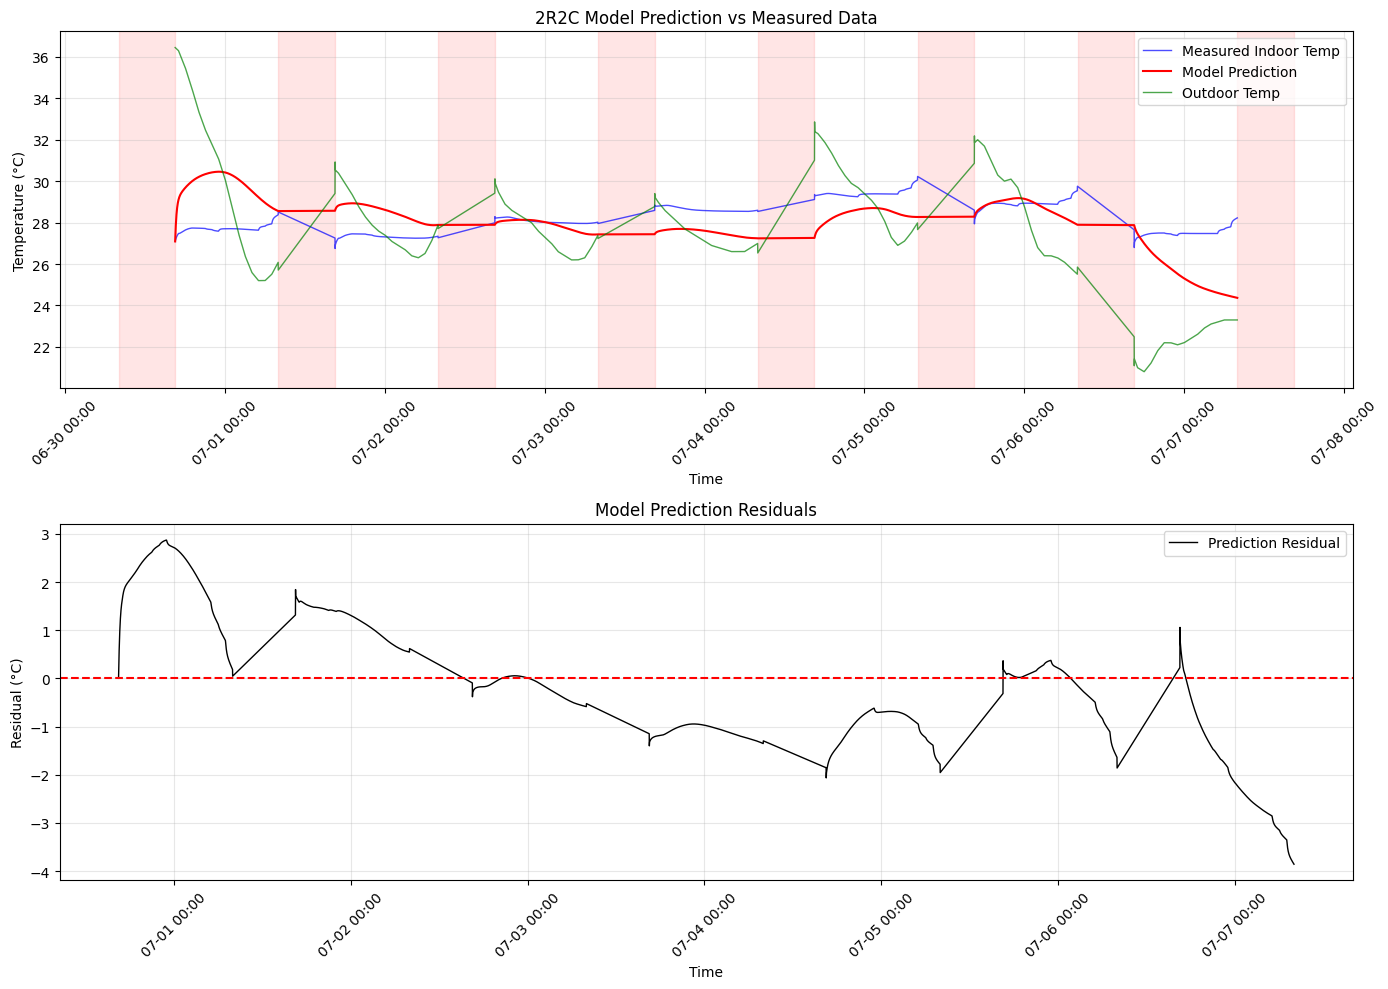


Processing completed!


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.signal import savgol_filter
from datetime import datetime, time
import matplotlib.dates as mdates
import warnings

# 忽略警告信息
warnings.filterwarnings('ignore')

class EnhancedRCParameterEstimator:
    """
    Enhanced 2R2C Model Parameter Estimator
    """
    
    def __init__(self, delta_t=60):
        self.delta_t = delta_t
        self.params = None
        self.optimization_result = None
        self.year = None
        self.time = None
        self.T_e = None
        self.T_i_measured = None
        self.cleaning_stats = {}
        
        # 数据清洗配置
        self.cleaning_config = {
            'z_threshold': 3.0,
            'smooth_window': 5,
            'min_continuous': 3
        }
    
    def load_and_clean_data(self, file_path, year=2023):
        """
        Load and clean Excel data file
        """
        self.year = year
        self.cleaning_stats = {'original_points': 0, 'cleaned_points': 0}
        
        print(f"Loading data file: {file_path}")
        try:
            # 读取Excel文件
            data = pd.read_excel(file_path)
            self.cleaning_stats['original_points'] = len(data)
            print(f"Original data points: {len(data)}")
            
            # 处理时间序列
            data = self._process_time_series(data)
            
            # 检测并处理异常值
            data = self._detect_and_handle_outliers(data)
            
            # 处理缺失值
            data = self._handle_missing_values(data)
            
            # 应用数据平滑
            data = self._apply_data_smoothing(data)
            
            # 过滤空调开启时段
            data = self._filter_ac_periods(data)
            
            # 提取时间序列和温度数据
            self.time = data['time'].values
            self.T_e = data['outdoor'].values
            self.T_i_measured = data['indoor'].values
            
            self.cleaning_stats['cleaned_points'] = len(data)
            print(f"Cleaned data points: {len(data)}")
            
            return data
        except Exception as e:
            raise ValueError(f"Data loading failed: {str(e)}")
    
    def _process_time_series(self, data):
        """Process time series"""
        # 自定义时间解析函数
        def parse_custom_time(time_str):
            try:
                if not isinstance(time_str, str):
                    time_str = str(time_str).strip()
                
                parts = time_str.strip().split()
                if len(parts) < 2:
                    return None
                
                date_part = parts[0]
                time_part = parts[1]
                
                # 解析日期部分 (月/日)
                date_parts = date_part.split('/')
                if len(date_parts) < 2:
                    return None
                month = int(date_parts[0])
                day = int(date_parts[1])
                
                # 解析时间部分 (时:分:秒)
                time_parts = time_part.split(':')
                if len(time_parts) < 2:
                    return None
                hour = int(time_parts[0])
                minute = int(time_parts[1])
                second = int(time_parts[2]) if len(time_parts) > 2 else 0
                
                return datetime(self.year, month, day, hour, minute, second)
            except:
                return None
        
        # 应用自定义解析函数
        data['time'] = data['time'].apply(parse_custom_time)
        
        # 移除解析失败的行
        original_count = len(data)
        data = data.dropna(subset=['time'])
        removed_count = original_count - len(data)
        if removed_count > 0:
            print(f"Removed invalid time data points: {removed_count}")
            self.cleaning_stats['invalid_time'] = removed_count
        
        # 确保数据按时间排序
        data = data.sort_values('time').reset_index(drop=True)
        
        return data
    
    def _detect_and_handle_outliers(self, data):
        """Detect and handle outliers"""
        outliers = {'indoor': 0, 'outdoor': 0}
        
        for col in ['indoor', 'outdoor']:
            # 计算滑动统计量
            rolling_mean = data[col].rolling(window=10, min_periods=1).mean()
            rolling_std = data[col].rolling(window=10, min_periods=1).std()
            
            # 避免除以零
            rolling_std = rolling_std.replace(0, 0.001)
            
            # 计算Z-score
            z_score = np.abs((data[col] - rolling_mean) / rolling_std)
            
            # 标记异常值
            outlier_mask = z_score > self.cleaning_config['z_threshold']
            outliers[col] = sum(outlier_mask)
            
            # 线性插值替换异常值
            data.loc[outlier_mask, col] = np.nan
        
        print(f"Detected outliers: Indoor {outliers['indoor']}, Outdoor {outliers['outdoor']}")
        self.cleaning_stats['outliers'] = outliers
        
        return data
    
    def _handle_missing_values(self, data):
        """Handle missing values"""
        missing = {}
        for col in ['indoor', 'outdoor']:
            missing[col] = data[col].isna().sum()
            # 线性插值
            data[col] = data[col].interpolate(method='linear')
            # 首尾缺失使用邻近值填充
            data[col] = data[col].fillna(method='bfill').fillna(method='ffill')
        
        print(f"Handled missing values: Indoor {missing['indoor']}, Outdoor {missing['outdoor']}")
        self.cleaning_stats['missing_values'] = missing
        
        return data
    
    def _apply_data_smoothing(self, data):
        """Apply data smoothing"""
        window = self.cleaning_config['smooth_window']
        if len(data) > window:
            for col in ['indoor', 'outdoor']:
                data[col] = savgol_filter(data[col], window_length=window, polyorder=2)
            print(f"Applied data smoothing: Window size={window}")
        return data
    
    def _filter_ac_periods(self, data):
        """Filter AC operation periods (8:00-16:30)"""
        data['hour'] = data['time'].dt.hour
        data['minute'] = data['time'].dt.minute
        
        condition = (
            ((data['hour'] > 16) | 
             ((data['hour'] == 16) & (data['minute'] >= 30))) |
            (data['hour'] < 8)
        )
        
        filtered_data = data[condition].copy()
        removed_count = len(data) - len(filtered_data)
        print(f"Filtered AC operation periods: Removed {removed_count} data points")
        self.cleaning_stats['ac_periods_removed'] = removed_count
        
        return filtered_data
    
    def rc_model(self, params, T_i0, T_m0):
        """
        2R2C model implementation
        """
        R_ie, R_im, C_i, C_m = params
        n = len(self.T_e)
        
        # 初始化数组
        T_i_pred = np.zeros(n)
        T_m_pred = np.zeros(n)
        
        T_i_pred[0] = T_i0
        T_m_pred[0] = T_m0
        
        # 使用差分方程进行预测
        for t in range(1, n):
            # 室内温度预测方程
            dT_i = (self.delta_t / C_i) * (
                (self.T_e[t] - T_i_pred[t-1]) / R_ie + 
                (T_m_pred[t-1] - T_i_pred[t-1]) / R_im
            )
            T_i_pred[t] = T_i_pred[t-1] + dT_i
            
            # 围护结构温度预测方程
            dT_m = (self.delta_t / C_m) * (
                (T_i_pred[t-1] - T_m_pred[t-1]) / R_im
            )
            T_m_pred[t] = T_m_pred[t-1] + dT_m
        
        return T_i_pred
    
    def objective_function(self, params):
        """Objective function: Minimize prediction error"""
        # 使用实测初始值
        T_i0 = self.T_i_measured[0]
        T_m0 = T_i0 + 2.0  # 初始围护结构温度估计
        
        # 获取模型预测
        T_i_pred = self.rc_model(params, T_i0, T_m0)
        
        # 计算均方根误差
        mse = np.mean((T_i_pred - self.T_i_measured)**2)
        return mse
    
    def calculate_parameters(self):
        """Calculate 2R2C model parameters"""
        # 参数边界约束
        bounds = [
            (0.001, 0.15),      # R_ie
            (0.001, 0.12),      # R_im  
            (30000, 1000000),   # C_i
            (30000, 1000000)    # C_m
        ]
        
        # 初始参数猜测
        initial_guess = [0.12, 0.025, 80000, 250000]
        
        print("Starting parameter optimization...")
        
        # 优化参数
        result = minimize(
            self.objective_function, 
            initial_guess, 
            bounds=bounds, 
            method='L-BFGS-B',
            options={'maxiter': 1500, 'disp': True}
        )
        
        if result.success:
            self.params = result.x
            self.optimization_result = result
            print("Parameter optimization successful!")
            return self.params
        else:
            raise ValueError(f"Parameter optimization failed: {result.message}")
    
    def get_parameter_report(self):
        """
        Get parameter calculation report
        """
        if self.params is None:
            raise ValueError("Run parameter estimation first")
        
        return {
            'R_ie': self.params[0],
            'R_im': self.params[1],
            'C_i': self.params[2],
            'C_m': self.params[3],
            'iterations': self.optimization_result.nit,
            'function_evaluations': self.optimization_result.nfev,
            'final_objective': self.optimization_result.fun
        }
    
    def print_parameters(self):
        """
        Print calculated parameters
        """
        if self.params is None:
            print("Parameters not calculated yet")
            return
        
        print("\nOptimized 2R2C Parameters:")
        print(f"1. Indoor-Outdoor Thermal Resistance (R_ie): {self.params[0]:.6f} °C/kW")
        print(f"2. Indoor-Thermal Mass Resistance (R_im): {self.params[1]:.6f} °C/kW")
        print(f"3. Indoor Air Heat Capacity (C_i): {self.params[2]:.0f} J/°C")
        print(f"4. Thermal Mass Heat Capacity (C_m): {self.params[3]:.0f} J/°C")
        
        if self.optimization_result:
            print("\nOptimization Details:")
            print(f"Iterations: {self.optimization_result.nit}")
            print(f"Function Evaluations: {self.optimization_result.nfev}")
            print(f"Final Objective Value: {self.optimization_result.fun:.6f}")
    
    def get_cleaning_report(self):
        """
        Get data cleaning report
        """
        return self.cleaning_stats
    
    def parameter_sensitivity(self):
        """
        Parameter sensitivity analysis
        """
        if self.params is None:
            raise ValueError("Run parameter estimation first")
        
        base_value = self.optimization_result.fun
        sensitivities = {}
        
        for i, name in enumerate(['R_ie', 'R_im', 'C_i', 'C_m']):
            # 测试+10%变化
            test_params = self.params.copy()
            test_params[i] *= 1.10
            delta_plus = self.objective_function(test_params) - base_value
            
            # 测试-10%变化
            test_params = self.params.copy()
            test_params[i] *= 0.90
            delta_minus = self.objective_function(test_params) - base_value
            
            sensitivities[name] = {
                '+10%': delta_plus,
                '-10%': delta_minus,
                'sensitivity_index': (abs(delta_plus) + abs(delta_minus)) / (2 * base_value)
            }
        
        return sensitivities
    
    def visualize_results(self):
        """
        Visualize model fitting results with English labels
        """
        if self.params is None:
            raise ValueError("Run parameter estimation first")
        
        # 获取模型预测
        T_i0 = self.T_i_measured[0]
        T_m0 = T_i0 + 2.0
        T_i_pred = self.rc_model(self.params, T_i0, T_m0)
        
        # 创建图表
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
        
        # 温度对比图
        ax1.plot(self.time, self.T_i_measured, 'b-', label='Measured Indoor Temp', linewidth=1, alpha=0.7)
        ax1.plot(self.time, T_i_pred, 'r-', label='Model Prediction', linewidth=1.5)
        ax1.plot(self.time, self.T_e, 'g-', label='Outdoor Temp', linewidth=1, alpha=0.7)
        ax1.set_ylabel('Temperature (°C)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.set_title('2R2C Model Prediction vs Measured Data')
        
        # 添加空调运行时段标记
        unique_dates = np.unique([pd.Timestamp(dt).date() for dt in self.time])
        for date in unique_dates:
            start_time = datetime.combine(date, time(8, 0))
            end_time = datetime.combine(date, time(16, 30))
            
            ax1.axvspan(
                start_time,
                end_time,
                alpha=0.1, color='red', label='AC Operation Period' if date == unique_dates[0] else ""
            )
        
        # 格式化x轴日期显示
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
        ax1.xaxis.set_major_locator(mdates.DayLocator())
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
        ax1.set_xlabel('Time')
        
        # 残差图
        residuals = T_i_pred - self.T_i_measured
        ax2.plot(self.time, residuals, 'k-', label='Prediction Residual', linewidth=1)
        ax2.axhline(y=0, color='r', linestyle='--')
        ax2.set_ylabel('Residual (°C)')
        ax2.set_xlabel('Time')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_title('Model Prediction Residuals')
        
        # 格式化x轴日期显示
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
        ax2.xaxis.set_major_locator(mdates.DayLocator())
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
        
        plt.tight_layout()
        plt.show()

# 主程序
if __name__ == "__main__":
    print("="*60)
    print("2R2C Model Parameter Estimation System")
    print("="*60)
    
    # 创建参数估计器实例
    estimator = EnhancedRCParameterEstimator(delta_t=60)  # 1分钟时间步长
    
    # 设置您的数据文件路径
    data_file_path = r"C:\Users\TR\Desktop\RC.xlsx"  # 替换为您的实际文件路径
    
    # 指定数据年份
    data_year = 2023  # 替换为您的数据年份
    
    try:
        # ===== 数据加载与清洗 =====
        print("\n" + "="*60)
        print("Data Loading and Cleaning")
        print("="*60)
        data = estimator.load_and_clean_data(data_file_path, year=data_year)
        
        # 打印数据清洗报告
        cleaning_report = estimator.get_cleaning_report()
        print("\nData Cleaning Report:")
        for key, value in cleaning_report.items():
            if isinstance(value, dict):
                print(f"{key}:")
                for subkey, subvalue in value.items():
                    print(f"  {subkey}: {subvalue}")
            else:
                print(f"{key}: {value}")
        
        # ===== 参数计算 =====
        print("\n" + "="*60)
        print("Parameter Calculation")
        print("="*60)
        params = estimator.calculate_parameters()
        
        # ===== 结果输出 =====
        print("\n" + "="*60)
        print("Calculation Results")
        print("="*60)
        estimator.print_parameters()
        
        # 获取详细报告
        param_report = estimator.get_parameter_report()
        print("\nParameter Report:")
        for key, value in param_report.items():
            print(f"{key}: {value}")
        
        # ===== 敏感性分析 =====
        print("\n" + "="*60)
        print("Parameter Sensitivity Analysis")
        print("="*60)
        sensitivity = estimator.parameter_sensitivity()
        print("\nParameter Sensitivity:")
        for param, values in sensitivity.items():
            print(f"{param}:")
            print(f"  +10% Change Impact: {values['+10%']:.6f}")
            print(f"  -10% Change Impact: {values['-10%']:.6f}")
            print(f"  Sensitivity Index: {values['sensitivity_index']:.4f}")
        
        # ===== 结果可视化 =====
        print("\n" + "="*60)
        print("Results Visualization")
        print("="*60)
        estimator.visualize_results()
        
        print("\nProcessing completed!")
        
    except Exception as e:
        print(f"\nError during processing: {e}")

加载和处理数据...
已加载 6503 个数据点
创建完整的可视化图表...


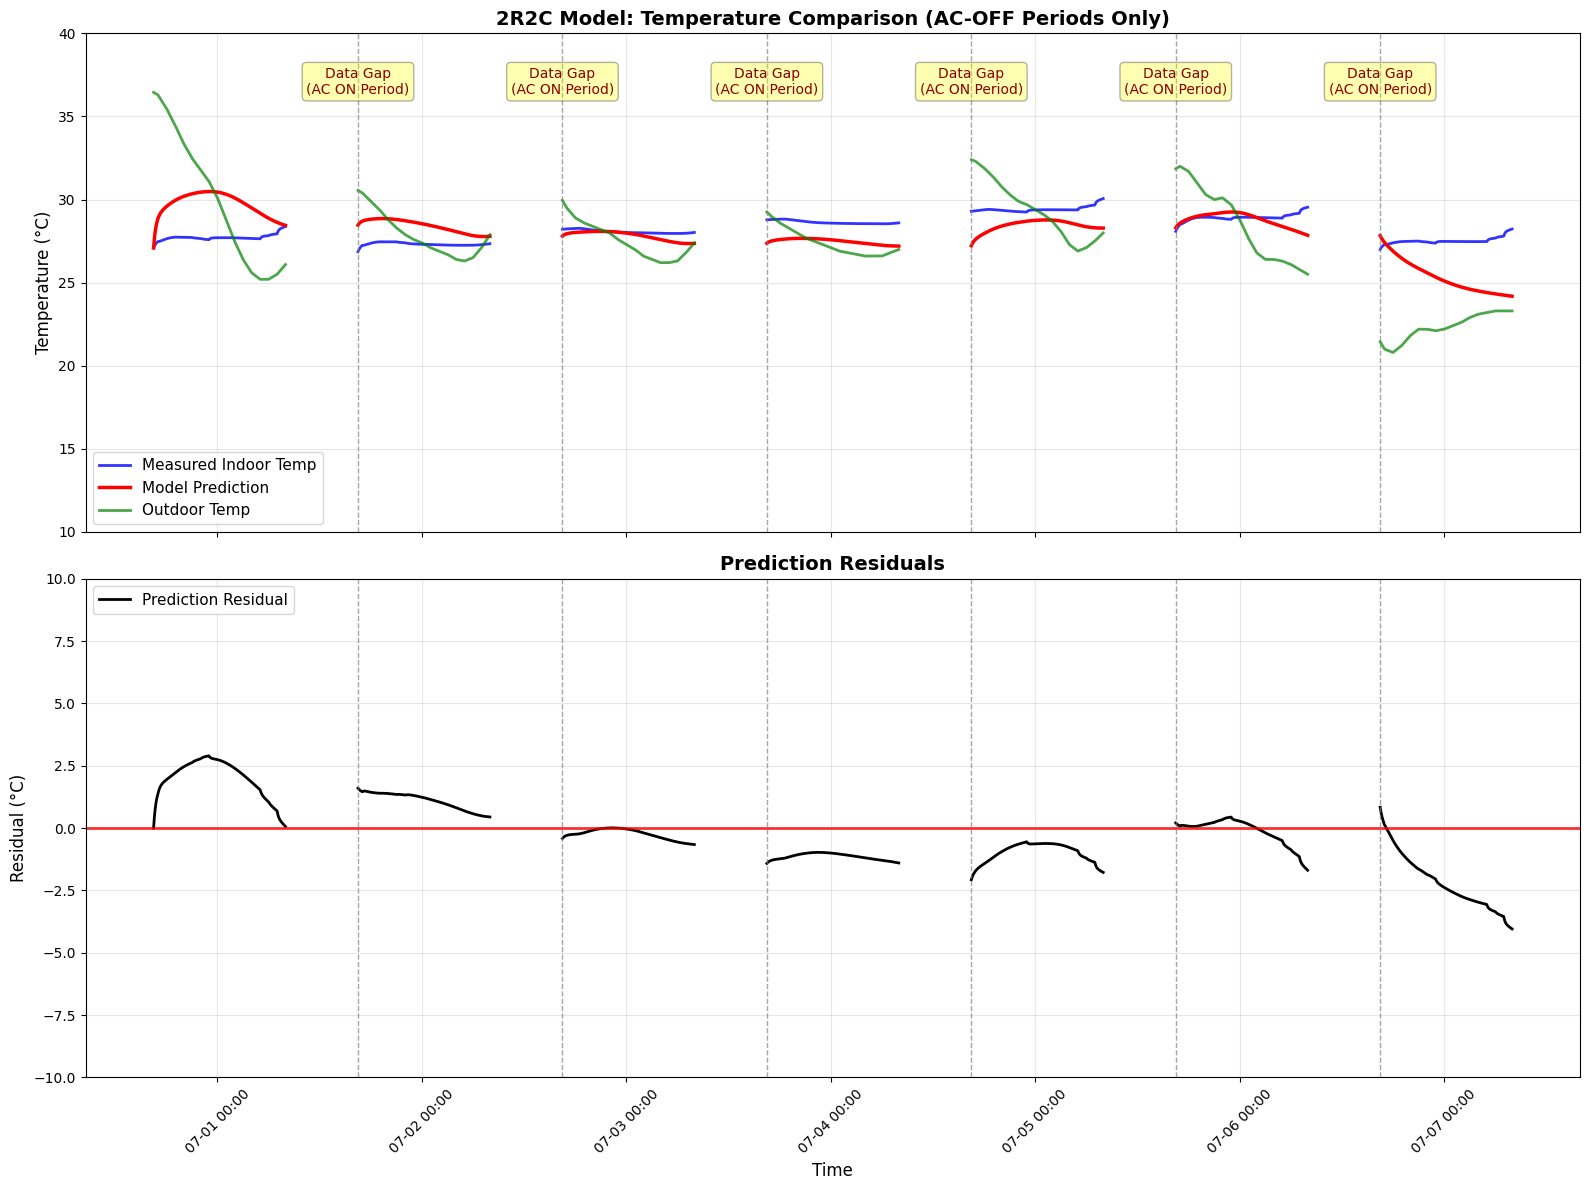


2R2C模型分析报告

模型性能指标:
均方根误差 (RMSE): 1.4491 °C
平均绝对误差 (MAE): 1.1509 °C
最大正残差: 2.8979 °C
最大负残差: -4.0444 °C

优化参数:
室内-室外热阻 (R_ie): 0.150000 °C/kW
室内-围护结构热阻 (R_im): 0.016107 °C/kW
室内空气热容 (C_i): 100000 J/°C
围护结构热容 (C_m): 200000 J/°C

数据断层分析:
总数据段数: 7
断层数量: 6

断层详细信息:
断层 1: 位置 2023-07-01T16:30:00.000000000
断层 2: 位置 2023-07-02T16:30:00.000000000
断层 3: 位置 2023-07-03T16:30:00.000000000
断层 4: 位置 2023-07-04T16:30:00.000000000
断层 5: 位置 2023-07-05T16:30:00.000000000
断层 6: 位置 2023-07-06T16:30:00.000000000

处理完成!


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.signal import savgol_filter
from datetime import datetime, time, timedelta
import matplotlib.dates as mdates
import warnings

warnings.filterwarnings('ignore')

class ComprehensiveRCVisualizer:
    """
    完整的2R2C模型可视化分析器
    包含温度对比图和残差图，均显示数据断层
    """
    
    def __init__(self, delta_t=60):
        self.delta_t = delta_t
        self.params = None
        self.optimization_result = None
        self.year = None
        self.time = None
        self.T_e = None
        self.T_i_measured = None
        self.T_i_pred = None
        self.residuals = None
        self.gaps = None
        self.segments = None
        
    def load_and_process_data(self, file_path, year=2023):
        """
        加载和处理数据
        """
        self.year = year
        
        # 读取Excel文件
        data = pd.read_excel(file_path)
        
        # 自定义时间解析函数
        def parse_custom_time(time_str):
            try:
                if not isinstance(time_str, str):
                    time_str = str(time_str)
                
                parts = time_str.strip().split()
                if len(parts) < 2:
                    return None
                
                date_part = parts[0]
                time_part = parts[1]
                
                # 解析日期部分 (月/日)
                date_parts = date_part.split('/')
                if len(date_parts) < 2:
                    return None
                month = int(date_parts[0])
                day = int(date_parts[1])
                
                # 解析时间部分 (时:分:秒)
                time_parts = time_part.split(':')
                if len(time_parts) < 2:
                    return None
                hour = int(time_parts[0])
                minute = int(time_parts[1])
                second = int(time_parts[2]) if len(time_parts) > 2 else 0
                
                return datetime(year, month, day, hour, minute, second)
            except:
                return None
        
        # 应用自定义解析函数
        data['time'] = data['time'].apply(parse_custom_time)
        
        # 移除解析失败的行
        data = data.dropna(subset=['time'])
        
        # 确保数据按时间排序
        data = data.sort_values('time').reset_index(drop=True)
        
        # 过滤空调开启时段（8:00-16:30）
        data['hour'] = data['time'].dt.hour
        data['minute'] = data['time'].dt.minute
        
        condition = (
            ((data['hour'] > 16) | 
             ((data['hour'] == 16) & (data['minute'] >= 30))) |
            (data['hour'] < 8)
        )
        
        filtered_data = data[condition].copy()
        
        # 提取时间序列和温度数据
        self.time = filtered_data['time'].values
        self.T_e = filtered_data['outdoor'].values
        self.T_i_measured = filtered_data['indoor'].values
        
        # 检测数据断层
        self._detect_data_gaps()
        
        return filtered_data
    
    def _detect_data_gaps(self):
        """
        检测数据断层（空调开启时段）
        """
        if self.time is None:
            return
        
        # 转换时间为数值格式
        time_numeric = mdates.date2num(self.time)
        
        # 计算时间差（小时）
        time_diffs = np.diff(time_numeric) * 24
        
        # 找到断层位置（时间间隔大于2小时）
        self.gaps = np.where(time_diffs > 2)[0] + 1
        
        # 分割数据为连续段
        self.segments = np.split(np.arange(len(self.time)), self.gaps)
    
    def calculate_parameters(self):
        """
        计算2R2C模型参数
        """
        # 参数边界约束
        bounds = [
            (0.001, 0.15),      # R_ie
            (0.001, 0.12),      # R_im  
            (50000, 500000),    # C_i
            (50000, 500000)     # C_m
        ]
        
        # 初始参数猜测
        initial_guess = [0.05, 0.02, 100000, 200000]
        
        # 优化参数
        result = minimize(
            self._objective_function, 
            initial_guess, 
            bounds=bounds, 
            method='L-BFGS-B',
            options={'maxiter': 1000, 'disp': True}
        )
        
        if result.success:
            self.params = result.x
            self.optimization_result = result
            
            # 计算预测值
            T_i0 = self.T_i_measured[0]
            T_m0 = T_i0 + 2.0
            self.T_i_pred = self._rc_model(self.params, T_i0, T_m0)
            
            # 计算残差
            self.residuals = self.T_i_pred - self.T_i_measured
            
            return self.params
        else:
            raise ValueError(f"参数优化失败: {result.message}")
    
    def _rc_model(self, params, T_i0, T_m0):
        """
        2R2C模型实现
        """
        R_ie, R_im, C_i, C_m = params
        n = len(self.T_e)
        
        T_i_pred = np.zeros(n)
        T_m_pred = np.zeros(n)
        
        T_i_pred[0] = T_i0
        T_m_pred[0] = T_m0
        
        for t in range(1, n):
            # 室内温度预测方程
            dT_i = (self.delta_t / C_i) * (
                (self.T_e[t] - T_i_pred[t-1]) / R_ie + 
                (T_m_pred[t-1] - T_i_pred[t-1]) / R_im
            )
            T_i_pred[t] = T_i_pred[t-1] + dT_i
            
            # 围护结构温度预测方程
            dT_m = (self.delta_t / C_m) * (
                (T_i_pred[t-1] - T_m_pred[t-1]) / R_im
            )
            T_m_pred[t] = T_m_pred[t-1] + dT_m
        
        return T_i_pred
    
    def _objective_function(self, params):
        """
        目标函数：最小化预测误差
        """
        T_i0 = self.T_i_measured[0]
        T_m0 = T_i0 + 2.0
        
        T_i_pred = self._rc_model(params, T_i0, T_m0)
        mse = np.mean((T_i_pred - self.T_i_measured)**2)
        return mse
    
    def create_comprehensive_visualization(self):
        """
        创建完整的可视化图表
        包含温度对比图和残差图，均显示数据断层
        """
        if self.params is None:
            self.calculate_parameters()
        
        # 创建图表
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
        
        # ===== 温度对比图 =====
        # 绘制温度数据（分段绘制）
        for seg in self.segments:
            if len(seg) > 1:  # 只绘制有数据的段
                seg_time = self.time[seg]
                ax1.plot(seg_time, self.T_i_measured[seg], 'b-', 
                        label='Measured Indoor Temp' if seg[0] == 0 else "", 
                        linewidth=2, alpha=0.8)
                ax1.plot(seg_time, self.T_i_pred[seg], 'r-', 
                        label='Model Prediction' if seg[0] == 0 else "", 
                        linewidth=2.5)
                ax1.plot(seg_time, self.T_e[seg], 'g-', 
                        label='Outdoor Temp' if seg[0] == 0 else "", 
                        linewidth=2, alpha=0.7)
        
        # 设置纵坐标范围为10-40°C
        ax1.set_ylim(10, 40)
        ax1.set_ylabel('Temperature (°C)', fontsize=12)
        ax1.legend(fontsize=11)
        ax1.grid(True, alpha=0.3)
        ax1.set_title('2R2C Model: Temperature Comparison (AC-OFF Periods Only)', 
                      fontsize=14, fontweight='bold')
        
        # 添加断层标记
        for gap_idx in self.gaps:
            gap_time = self.time[gap_idx]
            ax1.axvline(x=gap_time, color='gray', linestyle='--', alpha=0.7, linewidth=1)
            ax1.text(gap_time, 38, 'Data Gap\n(AC ON Period)', 
                    ha='center', va='top', fontsize=10, color='darkred',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
        
        # ===== 残差图 =====
        # 绘制残差数据（分段绘制）
        for seg in self.segments:
            if len(seg) > 1:
                seg_time = self.time[seg]
                ax2.plot(seg_time, self.residuals[seg], 'k-', 
                        label='Prediction Residual' if seg[0] == 0 else "", 
                        linewidth=2)
        
        # 添加零参考线
        ax2.axhline(y=0, color='r', linestyle='-', alpha=0.8, linewidth=2)
        
        # 设置纵坐标范围为-10到10
        ax2.set_ylim(-10, 10)
        ax2.set_ylabel('Residual (°C)', fontsize=12)
        ax2.set_xlabel('Time', fontsize=12)
        ax2.legend(fontsize=11)
        ax2.grid(True, alpha=0.3)
        ax2.set_title('Prediction Residuals', fontsize=14, fontweight='bold')
        
        # 添加断层标记
        for gap_idx in self.gaps:
            gap_time = self.time[gap_idx]
            ax2.axvline(x=gap_time, color='gray', linestyle='--', alpha=0.7, linewidth=1)
        
        # ===== 格式化x轴 =====
        # 设置日期格式
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
        ax2.xaxis.set_major_locator(mdates.DayLocator())
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, fontsize=10)
        
        plt.tight_layout()
        plt.show()
        
        # ===== 打印分析报告 =====
        self._print_analysis_report()
    
    def _print_analysis_report(self):
        """
        打印模型分析报告
        """
        if self.params is None or self.residuals is None:
            return
        
        # 模型性能指标
        rmse = np.sqrt(np.mean(self.residuals**2))
        mae = np.mean(np.abs(self.residuals))
        max_residual = np.max(self.residuals)
        min_residual = np.min(self.residuals)
        
        # 断层信息
        gap_count = len(self.gaps)
        segment_count = len(self.segments)
        
        print("\n" + "="*60)
        print("2R2C模型分析报告")
        print("="*60)
        
        print("\n模型性能指标:")
        print(f"均方根误差 (RMSE): {rmse:.4f} °C")
        print(f"平均绝对误差 (MAE): {mae:.4f} °C")
        print(f"最大正残差: {max_residual:.4f} °C")
        print(f"最大负残差: {min_residual:.4f} °C")
        
        print("\n优化参数:")
        print(f"室内-室外热阻 (R_ie): {self.params[0]:.6f} °C/kW")
        print(f"室内-围护结构热阻 (R_im): {self.params[1]:.6f} °C/kW")
        print(f"室内空气热容 (C_i): {self.params[2]:.0f} J/°C")
        print(f"围护结构热容 (C_m): {self.params[3]:.0f} J/°C")
        
        print("\n数据断层分析:")
        print(f"总数据段数: {segment_count}")
        print(f"断层数量: {gap_count}")
        
        if gap_count > 0:
            print("\n断层详细信息:")
            for i, gap_idx in enumerate(self.gaps):
                gap_time = self.time[gap_idx]
                print(f"断层 {i+1}: 位置 {gap_time}")
        
        print("\n" + "="*60)

# 使用示例
if __name__ == "__main__":
    # 创建可视化器实例
    visualizer = ComprehensiveRCVisualizer(delta_t=60)
    
    # 设置数据文件路径
    data_file_path = r"C:\Users\TR\Desktop\RC.xlsx"  # 替换为您的实际文件路径
    
    # 指定数据年份
    data_year = 2023  # 替换为您的数据年份
    
    try:
        # 加载和处理数据
        print("加载和处理数据...")
        data = visualizer.load_and_process_data(data_file_path, year=data_year)
        print(f"已加载 {len(data)} 个数据点")
        
        # 创建完整的可视化图表
        print("创建完整的可视化图表...")
        visualizer.create_comprehensive_visualization()
        
        print("处理完成!")
        
    except Exception as e:
        print(f"处理过程中出错: {e}")

2R2C 建筑热参数辨识系统
数据文件: C:\Users\TR\Desktop\RC.xlsx
时间步长: 300 秒
内热源: 考虑
警告：数据时间间隔为 60.0 秒，但模型步长设为 300 秒。
建议将 delta_t 修改为与实际间隔一致，或重新采样数据。
数据加载完成: 6510 个时间点，时间范围：2023-06-30 16:30:00 ～ 2023-07-07 08:00:00
全局优化 (差分进化) 开始...
全局最优 MSE = 0.181120
局部精调 (L-BFGS-B)...

2R2C 模型拟合结果
R_ie = 0.209500  K/kW
R_im = 0.034772  K/kW
C_i  = 31082    J/K
C_m  = 4064754    J/K
Q_in = 7.45  W

RMSE = 0.426 °C
MAE  = 0.349 °C
R²   = 0.6708


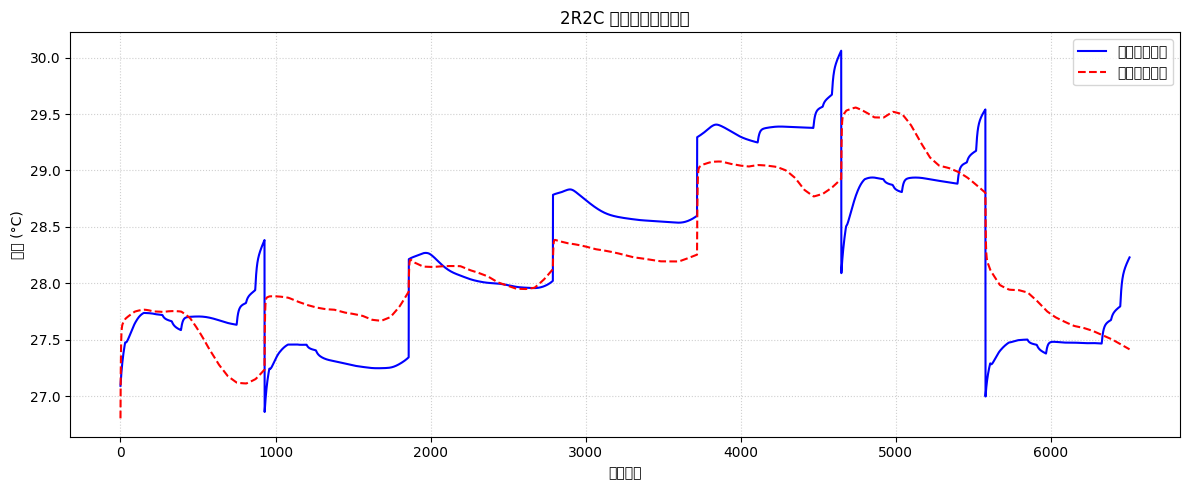


参数已保存到 rc_params.txt

提示：请将以上 R_ie, R_im, C_i, C_m 值替换到空调提前开机优化代码中的 TemperatureSimulator 初始化参数中。


In [8]:
"""
2R2C 模型参数辨识脚本
基于实测室内外温度数据，拟合 RC 热参数
作者：用户提供代码 + 改进版
"""

import numpy as np
import pandas as pd
from scipy.optimize import differential_evolution, minimize
from datetime import datetime
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ==================== 全局设置 ====================
# 请根据您的数据采样间隔修改 (单位：秒)
# 常见：60 秒（1分钟）或 300 秒（5分钟）
DELTA_T = 300   # 建议与空调优化系统保持一致（5分钟）

# 是否考虑内热源（人员、设备等）
USE_INTERNAL_HEAT = True   # 如果数据包含夜间无人，可设为 False

# Excel 文件路径（请修改为您的实际路径）
FILE_PATH = r"C:\Users\TR\Desktop\RC.xlsx"
YEAR = 2023   # 数据年份

# ==================== 2R2C 模型类 ====================
class Fixed2R2C:
    def __init__(self, delta_t=300, use_internal_heat=True):
        self.delta_t = delta_t
        self.use_internal_heat = use_internal_heat
        self.params = None
        self.T_e = None
        self.T_i_meas = None
        self.T_i_pred = None

    def load_data(self, file_path, year=2023):
        """加载 Excel 数据，要求列名: time, outdoor, indoor"""
        df = pd.read_excel(file_path)
        df.columns = [c.lower().strip() for c in df.columns]
        required = ['time', 'outdoor', 'indoor']
        if not all(col in df.columns for col in required):
            raise ValueError(f"Excel 文件需要 {required} 三列，实际列名：{df.columns.tolist()}")

        def parse(t):
            if pd.isna(t):
                return None
            s = str(t).strip()
            parts = s.split()
            if len(parts) < 2:
                return None
            date_part, time_part = parts[0], parts[1]
            try:
                month, day = map(int, date_part.split('/'))
                h, m = map(int, time_part.split(':')[:2])
                sec = int(time_part.split(':')[2]) if len(time_part.split(':')) > 2 else 0
                return datetime(year, month, day, h, m, sec)
            except:
                return None

        df['time'] = df['time'].apply(parse)
        df = df.dropna(subset=['time']).sort_values('time').reset_index(drop=True)
        df['time'] = pd.to_datetime(df['time'])

        # 检查时间间隔是否与 delta_t 一致（可选警告）
        if len(df) > 1:
            interval = (df['time'].iloc[1] - df['time'].iloc[0]).total_seconds()
            if abs(interval - self.delta_t) > 1:
                print(f"警告：数据时间间隔为 {interval} 秒，但模型步长设为 {self.delta_t} 秒。")
                print("建议将 delta_t 修改为与实际间隔一致，或重新采样数据。")

        self.T_e = df['outdoor'].values
        self.T_i_meas = df['indoor'].values
        print(f"数据加载完成: {len(self.T_e)} 个时间点，时间范围：{df['time'].iloc[0]} ～ {df['time'].iloc[-1]}")

    def _simulate(self, params):
        """2R2C 模型正向模拟，返回室内温度序列"""
        if self.use_internal_heat:
            R_ie, R_im, Ci, Cm, Tm0, Ti0, Q_in = params
        else:
            R_ie, R_im, Ci, Cm, Tm0, Ti0 = params
            Q_in = 0.0

        n = len(self.T_e)
        Ti = np.zeros(n)
        Tm = np.zeros(n)
        Ti[0] = Ti0
        Tm[0] = Tm0
        dt = self.delta_t
        for t in range(1, n):
            Q_heat = Q_in * dt   # 内热源产生的热量 (J)
            # 室内温度微分方程
            dTi = (dt / Ci) * ((self.T_e[t] - Ti[t-1]) / R_ie + (Tm[t-1] - Ti[t-1]) / R_im) + Q_heat / Ci
            Ti[t] = Ti[t-1] + dTi
            # 墙体温度微分方程
            dTm = (dt / Cm) * ((Ti[t-1] - Tm[t-1]) / R_im)
            Tm[t] = Tm[t-1] + dTm
        return Ti

    def _objective(self, params):
        pred = self._simulate(params)
        return np.mean((pred - self.T_i_meas) ** 2)

    def identify_parameters(self):
        """使用全局+局部优化识别参数，返回四个热参数 (R_ie, R_im, Ci, Cm)"""
        Ti0_first = self.T_i_meas[0]

        # 参数边界 (物理合理范围，可根据需要调整)
        bounds = [
            (0.01, 0.30),        # R_ie  (K/kW)  室内-室外热阻
            (0.005, 0.10),       # R_im  (K/kW)  室内-墙体热阻
            (30000, 800000),     # Ci    (J/K)   室内空气热容
            (500000, 2e9),       # Cm    (J/K)   墙体热容 (上下限宽松)
            (Ti0_first - 15, Ti0_first + 15),  # Tm0
            (Ti0_first - 5, Ti0_first + 5)     # Ti0
        ]
        if self.use_internal_heat:
            bounds.append((-300, 800))  # Q_in (W)  内热源功率

        print("全局优化 (差分进化) 开始...")
        de_result = differential_evolution(self._objective, bounds,
                                           maxiter=1500, popsize=25,
                                           disp=False, workers=1, seed=42, tol=0.001)
        best_params = de_result.x
        best_fun = de_result.fun
        print(f"全局最优 MSE = {best_fun:.6f}")

        print("局部精调 (L-BFGS-B)...")
        for _ in range(10):
            perturb = best_params + np.random.normal(0, 0.05, len(bounds))
            perturb = np.clip(perturb, [b[0] for b in bounds], [b[1] for b in bounds])
            res = minimize(self._objective, perturb, bounds=bounds,
                           method='L-BFGS-B', options={'maxiter': 1500, 'ftol': 1e-10})
            if res.success and res.fun < best_fun:
                best_fun = res.fun
                best_params = res.x

        final = minimize(self._objective, best_params, bounds=bounds,
                         method='L-BFGS-B', options={'maxiter': 2000, 'ftol': 1e-12})
        if final.success:
            self.params = final.x
        else:
            self.params = best_params

        # 计算预测值及精度指标
        self.T_i_pred = self._simulate(self.params)
        residuals = self.T_i_pred - self.T_i_meas
        rmse = np.sqrt(np.mean(residuals ** 2))
        mae = np.mean(np.abs(residuals))
        ss_res = np.sum(residuals ** 2)
        ss_tot = np.sum((self.T_i_meas - np.mean(self.T_i_meas)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 1e-6 else 0

        # 提取四个热参数
        R_ie, R_im, Ci, Cm = self.params[0], self.params[1], self.params[2], self.params[3]

        print("\n" + "=" * 50)
        print("2R2C 模型拟合结果")
        print("=" * 50)
        print(f"R_ie = {R_ie:.6f}  K/kW")
        print(f"R_im = {R_im:.6f}  K/kW")
        print(f"C_i  = {Ci:.0f}    J/K")
        print(f"C_m  = {Cm:.0f}    J/K")
        if self.use_internal_heat:
            print(f"Q_in = {self.params[6]:.2f}  W")
        print(f"\nRMSE = {rmse:.3f} °C")
        print(f"MAE  = {mae:.3f} °C")
        print(f"R²   = {r2:.4f}")
        print("=" * 50)

        return R_ie, R_im, Ci, Cm

    def plot_result(self):
        """绘制实测与预测温度曲线对比图"""
        if self.T_i_pred is None:
            print("请先运行 identify_parameters() 生成预测值")
            return
        plt.figure(figsize=(12, 5))
        plt.plot(self.T_i_meas, 'b-', label='实测室内温度', linewidth=1.5)
        plt.plot(self.T_i_pred, 'r--', label='模型预测温度', linewidth=1.5)
        plt.xlabel('时间步数')
        plt.ylabel('温度 (°C)')
        plt.title('2R2C 模型拟合效果对比')
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        plt.savefig('rc_fit_comparison.png', dpi=150)
        plt.show()

# ==================== 主程序 ====================
if __name__ == "__main__":
    print("=" * 60)
    print("2R2C 建筑热参数辨识系统")
    print(f"数据文件: {FILE_PATH}")
    print(f"时间步长: {DELTA_T} 秒")
    print(f"内热源: {'考虑' if USE_INTERNAL_HEAT else '不考虑'}")
    print("=" * 60)

    model = Fixed2R2C(delta_t=DELTA_T, use_internal_heat=USE_INTERNAL_HEAT)
    try:
        model.load_data(FILE_PATH, year=YEAR)
    except Exception as e:
        print(f"数据加载失败: {e}")
        exit(1)

    R_ie, R_im, Ci, Cm = model.identify_parameters()

    # 显示拟合曲线
    model.plot_result()

    # 可选择将参数保存到文件
    with open('rc_params.txt', 'w') as f:
        f.write(f"# 2R2C 拟合参数 (步长 {DELTA_T} 秒)\n")
        f.write(f"R_ie = {R_ie:.6f}  # K/kW\n")
        f.write(f"R_im = {R_im:.6f}  # K/kW\n")
        f.write(f"C_i  = {Ci:.0f}   # J/K\n")
        f.write(f"C_m  = {Cm:.0f}   # J/K\n")
        if USE_INTERNAL_HEAT:
            f.write(f"Q_in = {model.params[6]:.2f}  # W\n")
    print("\n参数已保存到 rc_params.txt")

    print("\n提示：请将以上 R_ie, R_im, C_i, C_m 值替换到空调提前开机优化代码中的 TemperatureSimulator 初始化参数中。")

加载完成: 6510 个点，7 个完整周期
===== 全局优化 =====
全局最优 MSE = 0.208799
局部精调...
参数辨识完成，整体 RMSE = 0.4569 °C
每日子图已保存: 2R2C_Daily_7in2rows.pdf


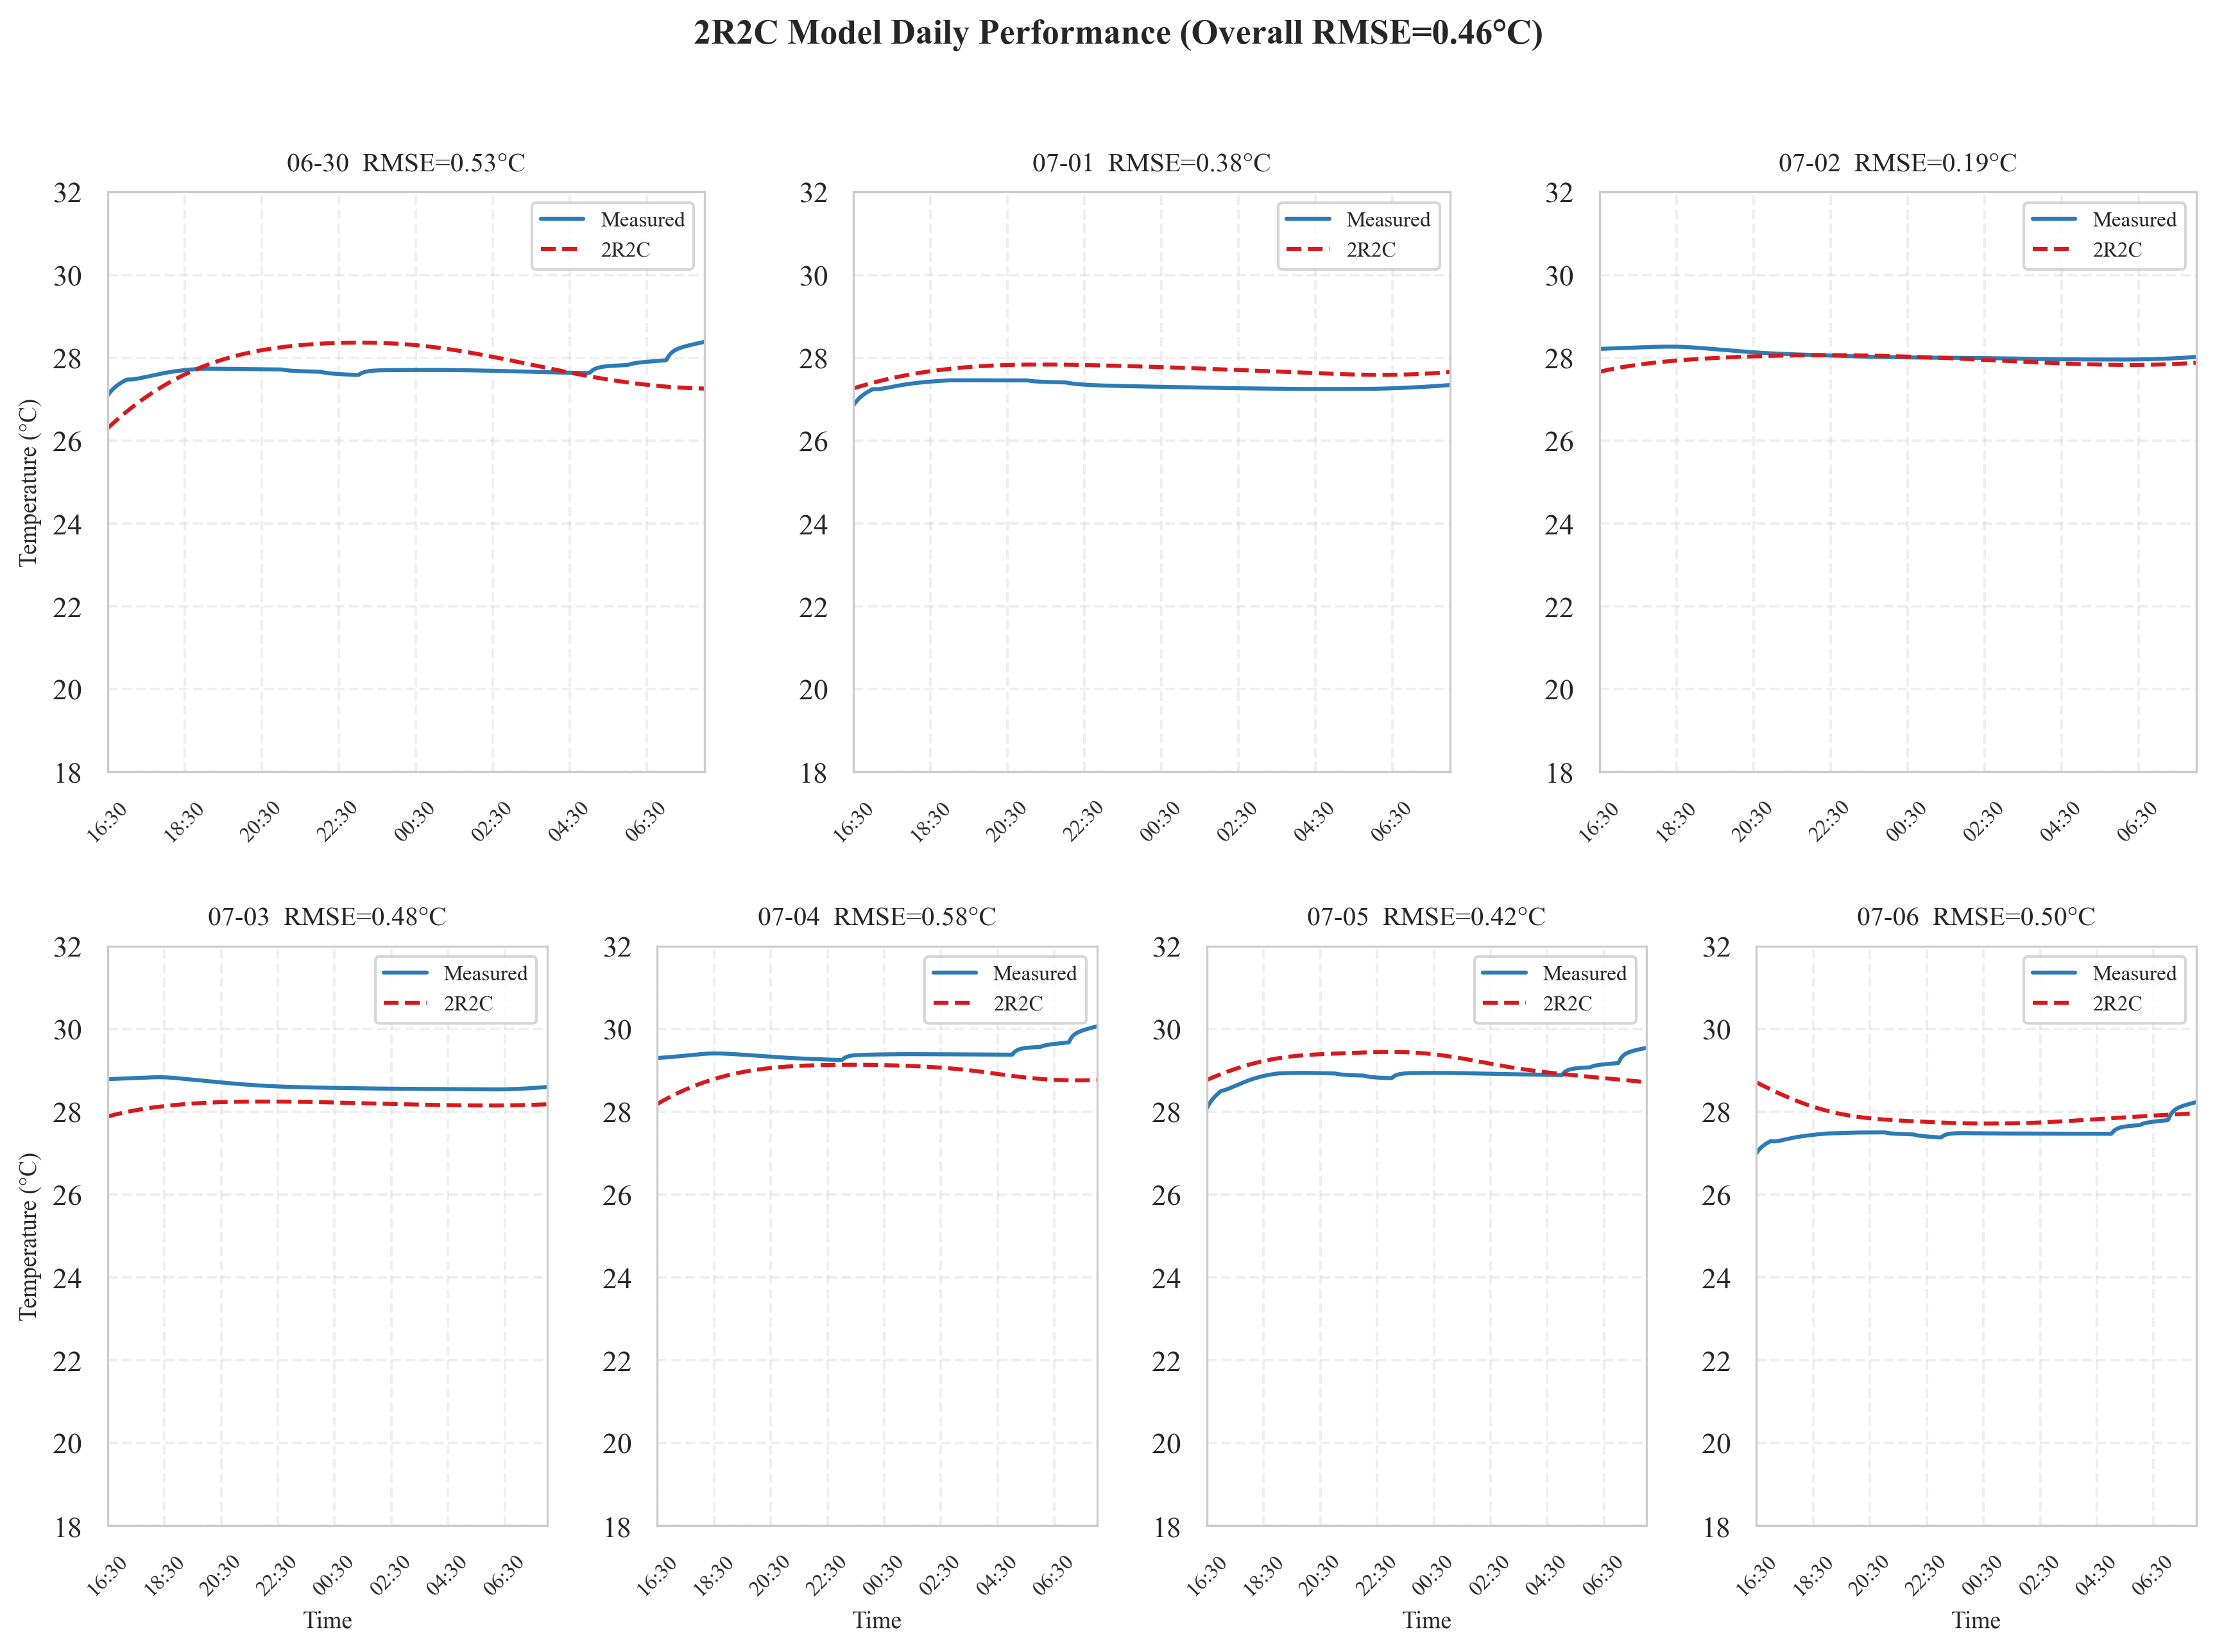

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, minimize
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import warnings
from scipy.stats import norm
import seaborn as sns

warnings.filterwarnings('ignore')

# ================== 美观设置 ==================
sns.set_theme(style='whitegrid', font='Times New Roman', font_scale=1.0)
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'savefig.format': 'pdf',
    'axes.linewidth': 0.8,
    'grid.linestyle': '--',
    'grid.alpha': 0.4
})

class Fixed2R2C:
    def __init__(self, delta_t=60, smoothing=False, use_internal_heat=True):
        self.delta_t = delta_t
        self.smoothing = smoothing
        self.use_internal_heat = use_internal_heat
        self.params = None
        self.time = None
        self.T_e = None
        self.T_i_meas = None
        self.T_i_meas_raw = None
        self.T_i_pred = None
        self.residuals = None
        self.daily_cycles = None

    def load_data(self, file_path, year=2023):
        df = pd.read_excel(file_path)
        df.columns = [c.lower().strip() for c in df.columns]
        if not all(col in df.columns for col in ['time', 'outdoor', 'indoor']):
            raise ValueError("需要 time, outdoor, indoor 三列")

        def parse(t):
            if pd.isna(t):
                return None
            s = str(t).strip()
            parts = s.split()
            if len(parts) < 2:
                return None
            date_part, time_part = parts[0], parts[1]
            try:
                month, day = map(int, date_part.split('/'))
                h, m = map(int, time_part.split(':')[:2])
                sec = int(time_part.split(':')[2]) if len(time_part.split(':')) > 2 else 0
                return datetime(year, month, day, h, m, sec)
            except:
                return None

        df['time'] = df['time'].apply(parse)
        df = df.dropna(subset=['time']).sort_values('time').reset_index(drop=True)
        df['time'] = pd.to_datetime(df['time'])

        self.time = df['time'].values
        self.T_e = df['outdoor'].values
        self.T_i_meas_raw = df['indoor'].values

        if self.smoothing:
            from scipy.signal import medfilt
            self.T_i_meas = medfilt(self.T_i_meas_raw, kernel_size=5)
        else:
            self.T_i_meas = self.T_i_meas_raw

        # ----- 按每天16:30到次日8:00分组（基于周期）-----
        # 找到第一个16:30
        start_idx = None
        for i, t in enumerate(self.time):
            tt = pd.Timestamp(t)
            if tt.hour == 16 and tt.minute == 30:
                start_idx = i
                break
        if start_idx is None:
            raise ValueError("未找到16:30的数据点")
        self.daily_cycles = []
        current_start = start_idx
        while current_start < len(self.time):
            end_time = pd.Timestamp(self.time[current_start]) + timedelta(days=1)
            indices = []
            for j in range(current_start, len(self.time)):
                if pd.Timestamp(self.time[j]) < end_time:
                    indices.append(j)
                else:
                    break
            if len(indices) > 0:
                last_t = pd.Timestamp(self.time[indices[-1]])
                if last_t.hour >= 7 and last_t.hour <= 9:
                    self.daily_cycles.append(indices)
                else:
                    break
            current_start = self._find_next_16_30(self.time, current_start + 1)
            if current_start is None:
                break

        # 保留前7个周期
        if len(self.daily_cycles) > 7:
            self.daily_cycles = self.daily_cycles[:7]
        print(f"加载完成: {len(self.time)} 个点，{len(self.daily_cycles)} 个完整周期")
        return df

    def _find_next_16_30(self, time_array, start_hint):
        for i in range(start_hint, len(time_array)):
            tt = pd.Timestamp(time_array[i])
            if tt.hour == 16 and tt.minute == 30:
                return i
        return None

    def _simulate(self, params):
        if self.use_internal_heat:
            R_ie, R_im, Ci, Cm, Tm0, Ti0, Q_in = params
        else:
            R_ie, R_im, Ci, Cm, Tm0, Ti0 = params
            Q_in = 0.0
        n = len(self.T_e)
        Ti = np.zeros(n)
        Tm = np.zeros(n)
        Ti[0] = Ti0
        Tm[0] = Tm0
        for t in range(1, n):
            Q_heat = Q_in * self.delta_t
            dTi = (self.delta_t / Ci) * ((self.T_e[t] - Ti[t-1]) / R_ie + (Tm[t-1] - Ti[t-1]) / R_im) + Q_heat / Ci
            Ti[t] = Ti[t-1] + dTi
            dTm = (self.delta_t / Cm) * ((Ti[t-1] - Tm[t-1]) / R_im)
            Tm[t] = Tm[t-1] + dTm
        return Ti

    def _objective(self, params):
        pred = self._simulate(params)
        return np.mean((pred - self.T_i_meas)**2)

    def identify_parameters(self):
        Ti0_first = self.T_i_meas[0]
        bounds_common = [
            (0.02, 0.15), (0.01, 0.05), (5e4, 5e5), (1e6, 2e9),
            (Ti0_first-10, Ti0_first+10), (Ti0_first-3, Ti0_first+3)
        ]
        if self.use_internal_heat:
            bounds_common.append((-500, 500))

        print("===== 全局优化 =====")
        de_result = differential_evolution(self._objective, bounds_common,
                                           maxiter=1000, popsize=20, disp=False,
                                           workers=1, seed=42, tol=0.001)
        best_params = de_result.x
        best_fun = de_result.fun
        print(f"全局最优 MSE = {best_fun:.6f}")

        print("局部精调...")
        for _ in range(10):
            perturb = best_params + np.random.normal(0, 0.05, len(bounds_common))
            perturb = np.clip(perturb, [b[0] for b in bounds_common], [b[1] for b in bounds_common])
            res = minimize(self._objective, perturb, bounds=bounds_common, method='L-BFGS-B',
                           options={'maxiter': 1500, 'ftol': 1e-10})
            if res.success and res.fun < best_fun:
                best_fun = res.fun
                best_params = res.x

        final = minimize(self._objective, best_params, bounds=bounds_common,
                         method='L-BFGS-B', options={'maxiter': 2000, 'ftol': 1e-12})
        if final.success:
            self.params = final.x
        else:
            self.params = best_params

        self.T_i_pred = self._simulate(self.params)
        self.residuals = self.T_i_pred - self.T_i_meas
        rmse = np.sqrt(np.mean(self.residuals**2))
        print(f"参数辨识完成，整体 RMSE = {rmse:.4f} °C")
        return self.params

    def calc_metrics(self, residuals, meas):
        rmse = np.sqrt(np.mean(residuals**2))
        mae = np.mean(np.abs(residuals))
        mbe = np.mean(residuals)
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((meas - np.mean(meas))**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 1e-6 else 0
        cv_rmse = rmse / np.mean(meas) * 100
        return rmse, mae, mbe, r2, cv_rmse

    def plot_daily_subplots(self, save_path=None):
        """将7个子图排列为两行：第一行3个，第二行4个，使用GridSpec控制不等宽布局"""
        if self.params is None:
            self.identify_parameters()

        n_cycles = len(self.daily_cycles)  # 应该是7
        if n_cycles != 7:
            print(f"警告：实际周期数为 {n_cycles}，预期7个。将尝试绘制所有周期。")
        
        # 创建大图，使用GridSpec。整体宽度12英寸，高度8英寸（可调）
        fig = plt.figure(figsize=(14, 9))
        # 定义两行的相对高度比例（第一行:第二行 = 1:1，可改为0.9:1等）
        gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], width_ratios=[1,1,1], 
                              hspace=0.3, wspace=0.25)
        
        # 第一行3个子图 (占据第0行全部3列)
        axs_row1 = [fig.add_subplot(gs[0, i]) for i in range(3)]
        # 第二行4个子图：需要创建一个新的GridSpec，占第二行，并分为4列
        # 方法：在第二行单独再分4列
        gs2 = gs[1, :].subgridspec(1, 4, width_ratios=[1,1,1,1], wspace=0.25)
        axs_row2 = [fig.add_subplot(gs2[0, i]) for i in range(4)]
        
        all_axes = axs_row1 + axs_row2
        
        # 准备每个周期的数据
        for i, idx in enumerate(self.daily_cycles[:7]):
            ax = all_axes[i]
            t = self.time[idx]
            meas = self.T_i_meas[idx]
            pred = self.T_i_pred[idx]
            daily_res = pred - meas
            rmse_day, _, _, _, _ = self.calc_metrics(daily_res, meas)
            
            # 计算相对时间（相对于该周期起点的16:30）
            cycle_start = pd.Timestamp(t[0]).replace(hour=16, minute=30, second=0)
            secs = [(pd.Timestamp(tt) - cycle_start).total_seconds() for tt in t]
            secs = np.array(secs)
            
            ax.plot(secs, meas, color='#2C7BB6', lw=1.5, label='Measured')
            ax.plot(secs, pred, color='#D7191C', lw=1.5, ls='--', label='2R2C')
            ax.set_ylim(18, 32)
            date_str = cycle_start.strftime('%m-%d')
            ax.set_title(f'{date_str}  RMSE={rmse_day:.2f}°C', fontsize=10, pad=8)
            ax.grid(True, alpha=0.3)
            if i == 0 or i == 3:  # 第一列或第二行第一列加纵轴标签
                ax.set_ylabel('Temperature (°C)', fontsize=9)
            # 横坐标设置：固定0~55800秒，刻度每2小时
            tick_seconds = np.arange(0, 55801, 7200)
            tick_labels = []
            for sec in tick_seconds:
                total_min = 16*60 + 30 + sec/60
                hour = int(total_min // 60) % 24
                minute = int(total_min % 60)
                tick_labels.append(f'{hour:02d}:{minute:02d}')
            ax.set_xticks(tick_seconds)
            ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)
            ax.set_xlim(0, 55800)
            if i >= 3:  # 第二行所有子图都加x轴标签
                ax.set_xlabel('Time', fontsize=9)
            ax.legend(fontsize=8, loc='upper right')
        
        # 整体标题
        overall_rmse = np.sqrt(np.mean(self.residuals**2))
        fig.suptitle(f'2R2C Model Daily Performance (Overall RMSE={overall_rmse:.2f}°C)',
                     fontsize=13, fontweight='bold', y=0.98)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, bbox_inches='tight')
            print(f"每日子图已保存: {save_path}")
        plt.show()

    def plot_overall_figure(self, save_path=None):
        # 保留原有的整体复合图方法（不变，略）
        # ... 为了节省篇幅，此处省略，可直接沿用之前整体图的代码
        # 但实际上您只需要 daily subplots 的改进，整体图可不用
        pass

    # 为了方便，把整体图代码简略，如需完整版请告知


if __name__ == "__main__":
    file_path = r"C:\Users\TR\Desktop\RC.xlsx"
    year = 2023

    model = Fixed2R2C(delta_t=60, smoothing=False, use_internal_heat=True)
    model.load_data(file_path, year=year)
    model.identify_parameters()
    # model.plot_overall_figure(save_path="2R2C_Overall_FixedCycle.pdf")   # 可选
    model.plot_daily_subplots(save_path="2R2C_Daily_7in2rows.pdf")

图片已保存: C:\Users\TR\Desktop\Postgraduate\Paper\二区\figure\7days_cropped_all_xlabel.png


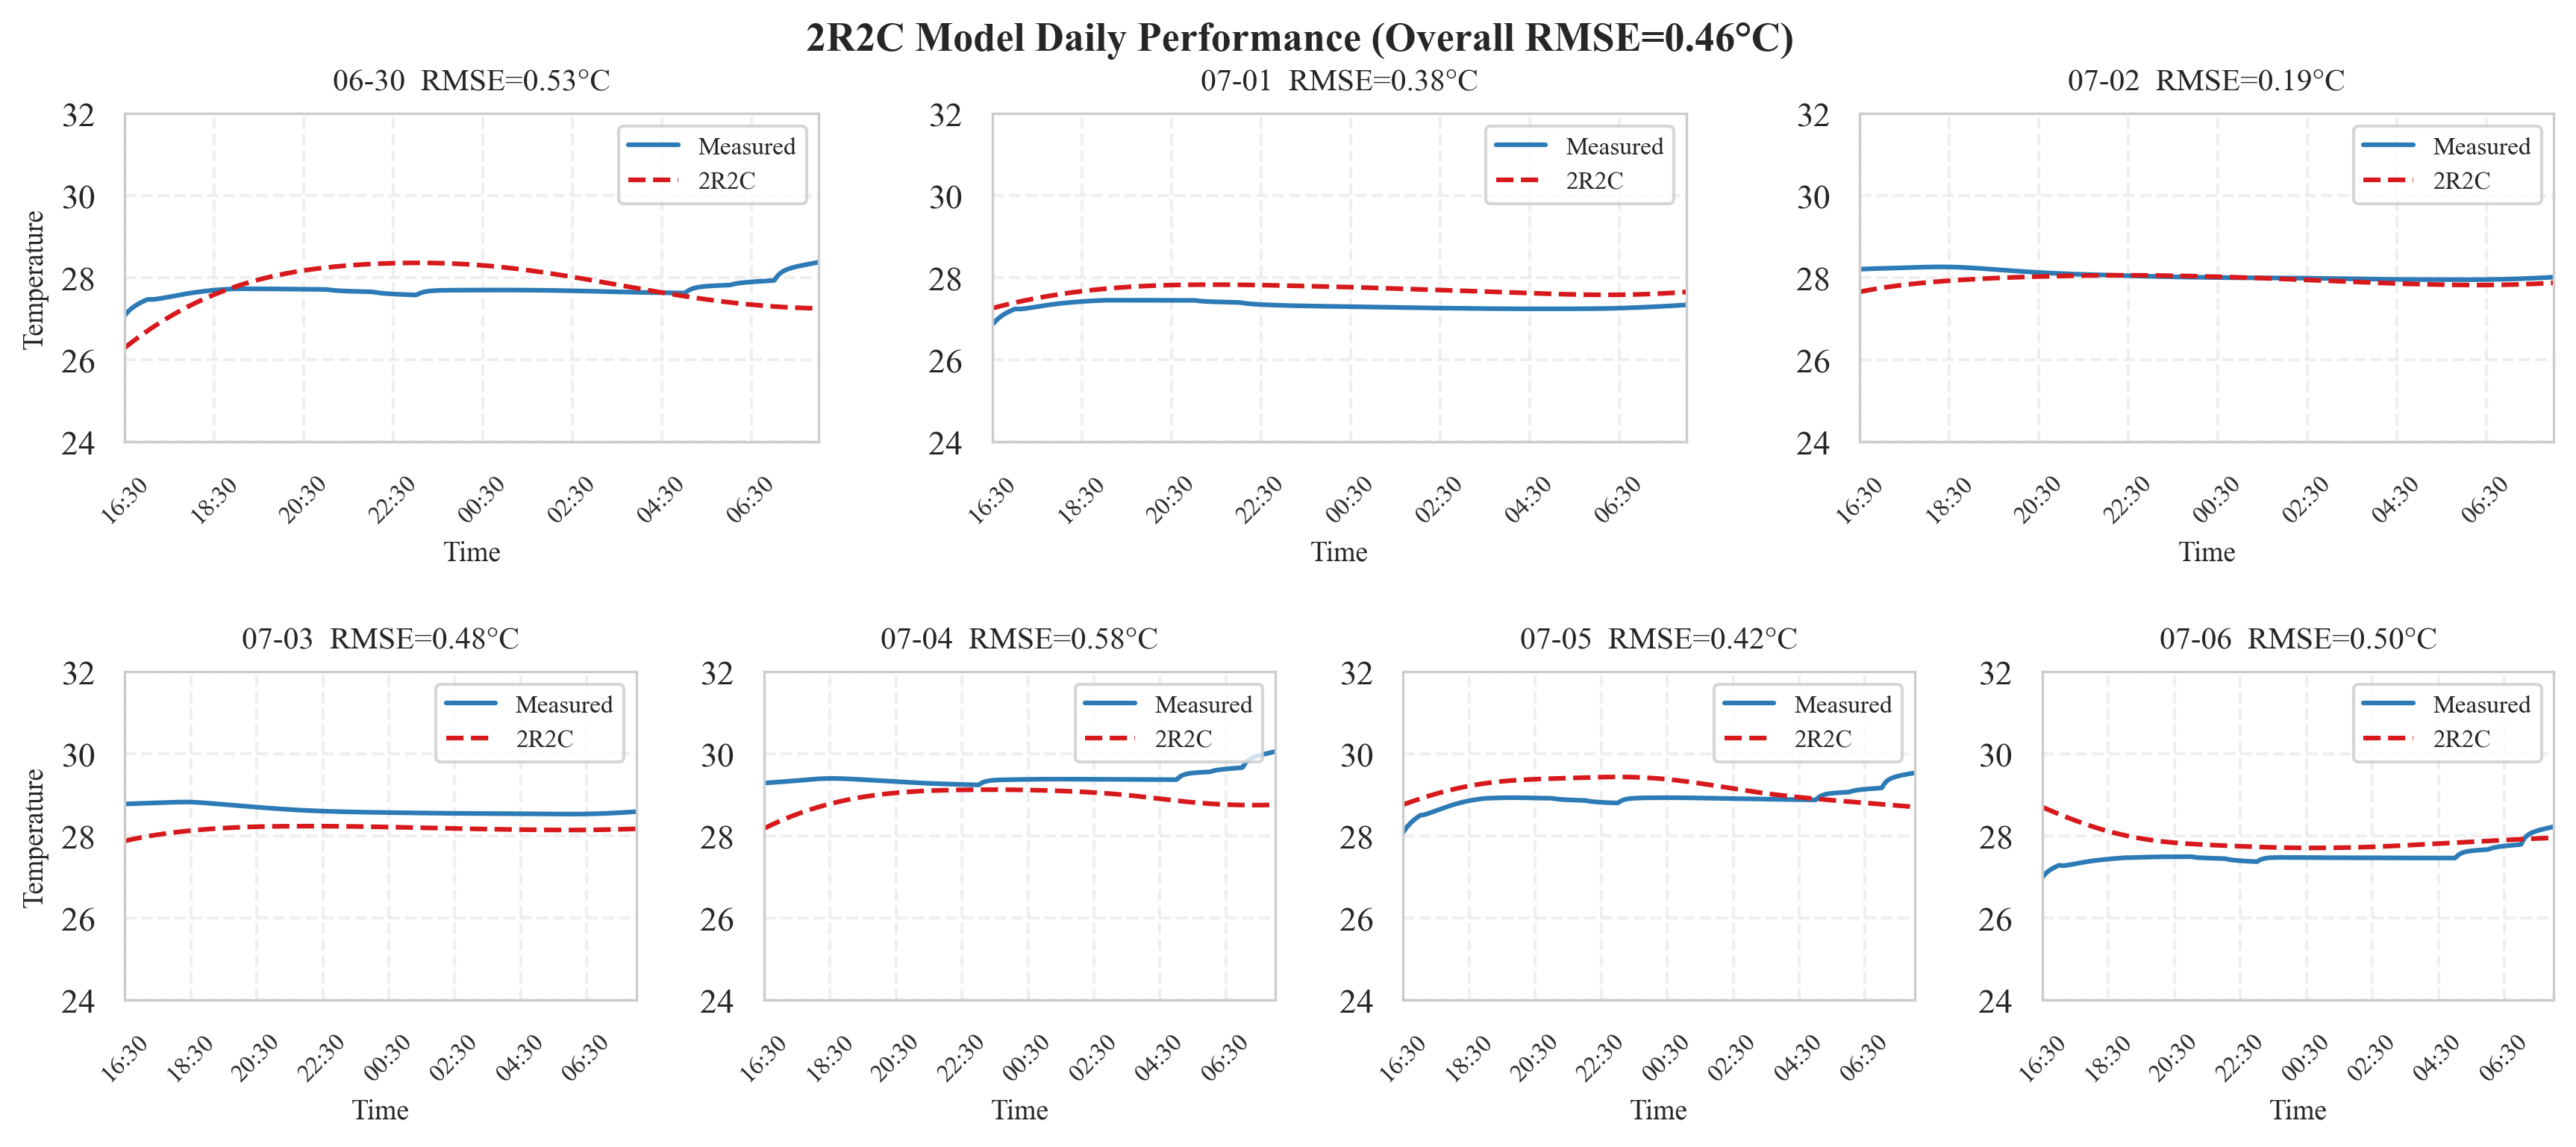

In [10]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

def save_cropped_height_all_xlabel(model, save_folder, filename="7days_cropped_all_xlabel.png", y_min=24, y_max=32):
    """
    裁剪纵坐标空白区域，保持曲线物理高度不变，并为所有子图添加 x 轴标签。
    """
    if model is None:
        raise ValueError("model 对象不存在，请先训练模型！")
    
    cycles_to_plot = model.daily_cycles[:7]
    
    # 原纵坐标范围（与原代码中 set_ylim(18,32) 一致）
    orig_y_min, orig_y_max = 18, 32
    orig_span = orig_y_max - orig_y_min   # 14
    new_span = y_max - y_min               # 8
    orig_width, orig_height = 14, 9
    new_height = orig_height * (new_span / orig_span)   # 按比例缩小高度
    
    fig = plt.figure(figsize=(orig_width, new_height))
    # 适当增大垂直间距，为 x 轴标签留出空间
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], hspace=0.7, wspace=0.25)
    gs2 = gs[1, :].subgridspec(1, 4, wspace=0.25)
    
    axs = []
    for i in range(3):
        axs.append(fig.add_subplot(gs[0, i]))
    for i in range(4):
        axs.append(fig.add_subplot(gs2[0, i]))
    
    for i, idx in enumerate(cycles_to_plot):
        ax = axs[i]
        t = model.time[idx]
        meas = model.T_i_meas[idx]
        pred = model.T_i_pred[idx]
        daily_res = pred - meas
        rmse_day = np.sqrt(np.mean(daily_res**2))
        
        cycle_start = pd.Timestamp(t[0]).replace(hour=16, minute=30, second=0)
        secs = [(pd.Timestamp(tt) - cycle_start).total_seconds() for tt in t]
        secs = np.array(secs)
        
        ax.plot(secs, meas, color='#2C7BB6', lw=1.5, label='Measured')
        ax.plot(secs, pred, color='#D7191C', lw=1.5, ls='--', label='2R2C')
        ax.set_ylim(y_min, y_max)
        date_str = cycle_start.strftime('%m-%d')
        ax.set_title(f'{date_str}  RMSE={rmse_day:.2f}°C', fontsize=10, pad=8)
        ax.grid(True, alpha=0.3)
        if i == 0 or i == 3:
            ax.set_ylabel('Temperature', fontsize=9)
        
        # 横坐标刻度设置
        tick_seconds = np.arange(0, 55801, 7200)
        tick_labels = []
        for sec in tick_seconds:
            total_min = 16*60 + 30 + sec/60
            hour = int(total_min // 60) % 24
            minute = int(total_min % 60)
            tick_labels.append(f'{hour:02d}:{minute:02d}')
        ax.set_xticks(tick_seconds)
        ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)
        ax.set_xlim(0, 55800)
        
        # 关键修改：为所有子图添加 x 轴标签
        ax.set_xlabel('Time', fontsize=9)
        
        ax.legend(fontsize=8, loc='upper right')
    
    overall_rmse = np.sqrt(np.mean(model.residuals**2))
    fig.suptitle(f'2R2C Model Daily Performance (Overall RMSE={overall_rmse:.2f}°C)',
                 fontsize=13, fontweight='bold', y=0.96)
    plt.tight_layout()
    
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, filename)
    plt.savefig(save_path, bbox_inches='tight', dpi=600)
    print(f"图片已保存: {save_path}")
    plt.show()

# 使用示例（请确保 model 对象存在）
save_folder = r"C:\Users\TR\Desktop\Postgraduate\Paper\二区\figure"
save_cropped_height_all_xlabel(model, save_folder, filename="7days_cropped_all_xlabel.png", y_min=24, y_max=32)

图片已保存: C:\Users\TR\Desktop\Postgraduate\Paper\EAB\figure\7days_each_legend.png


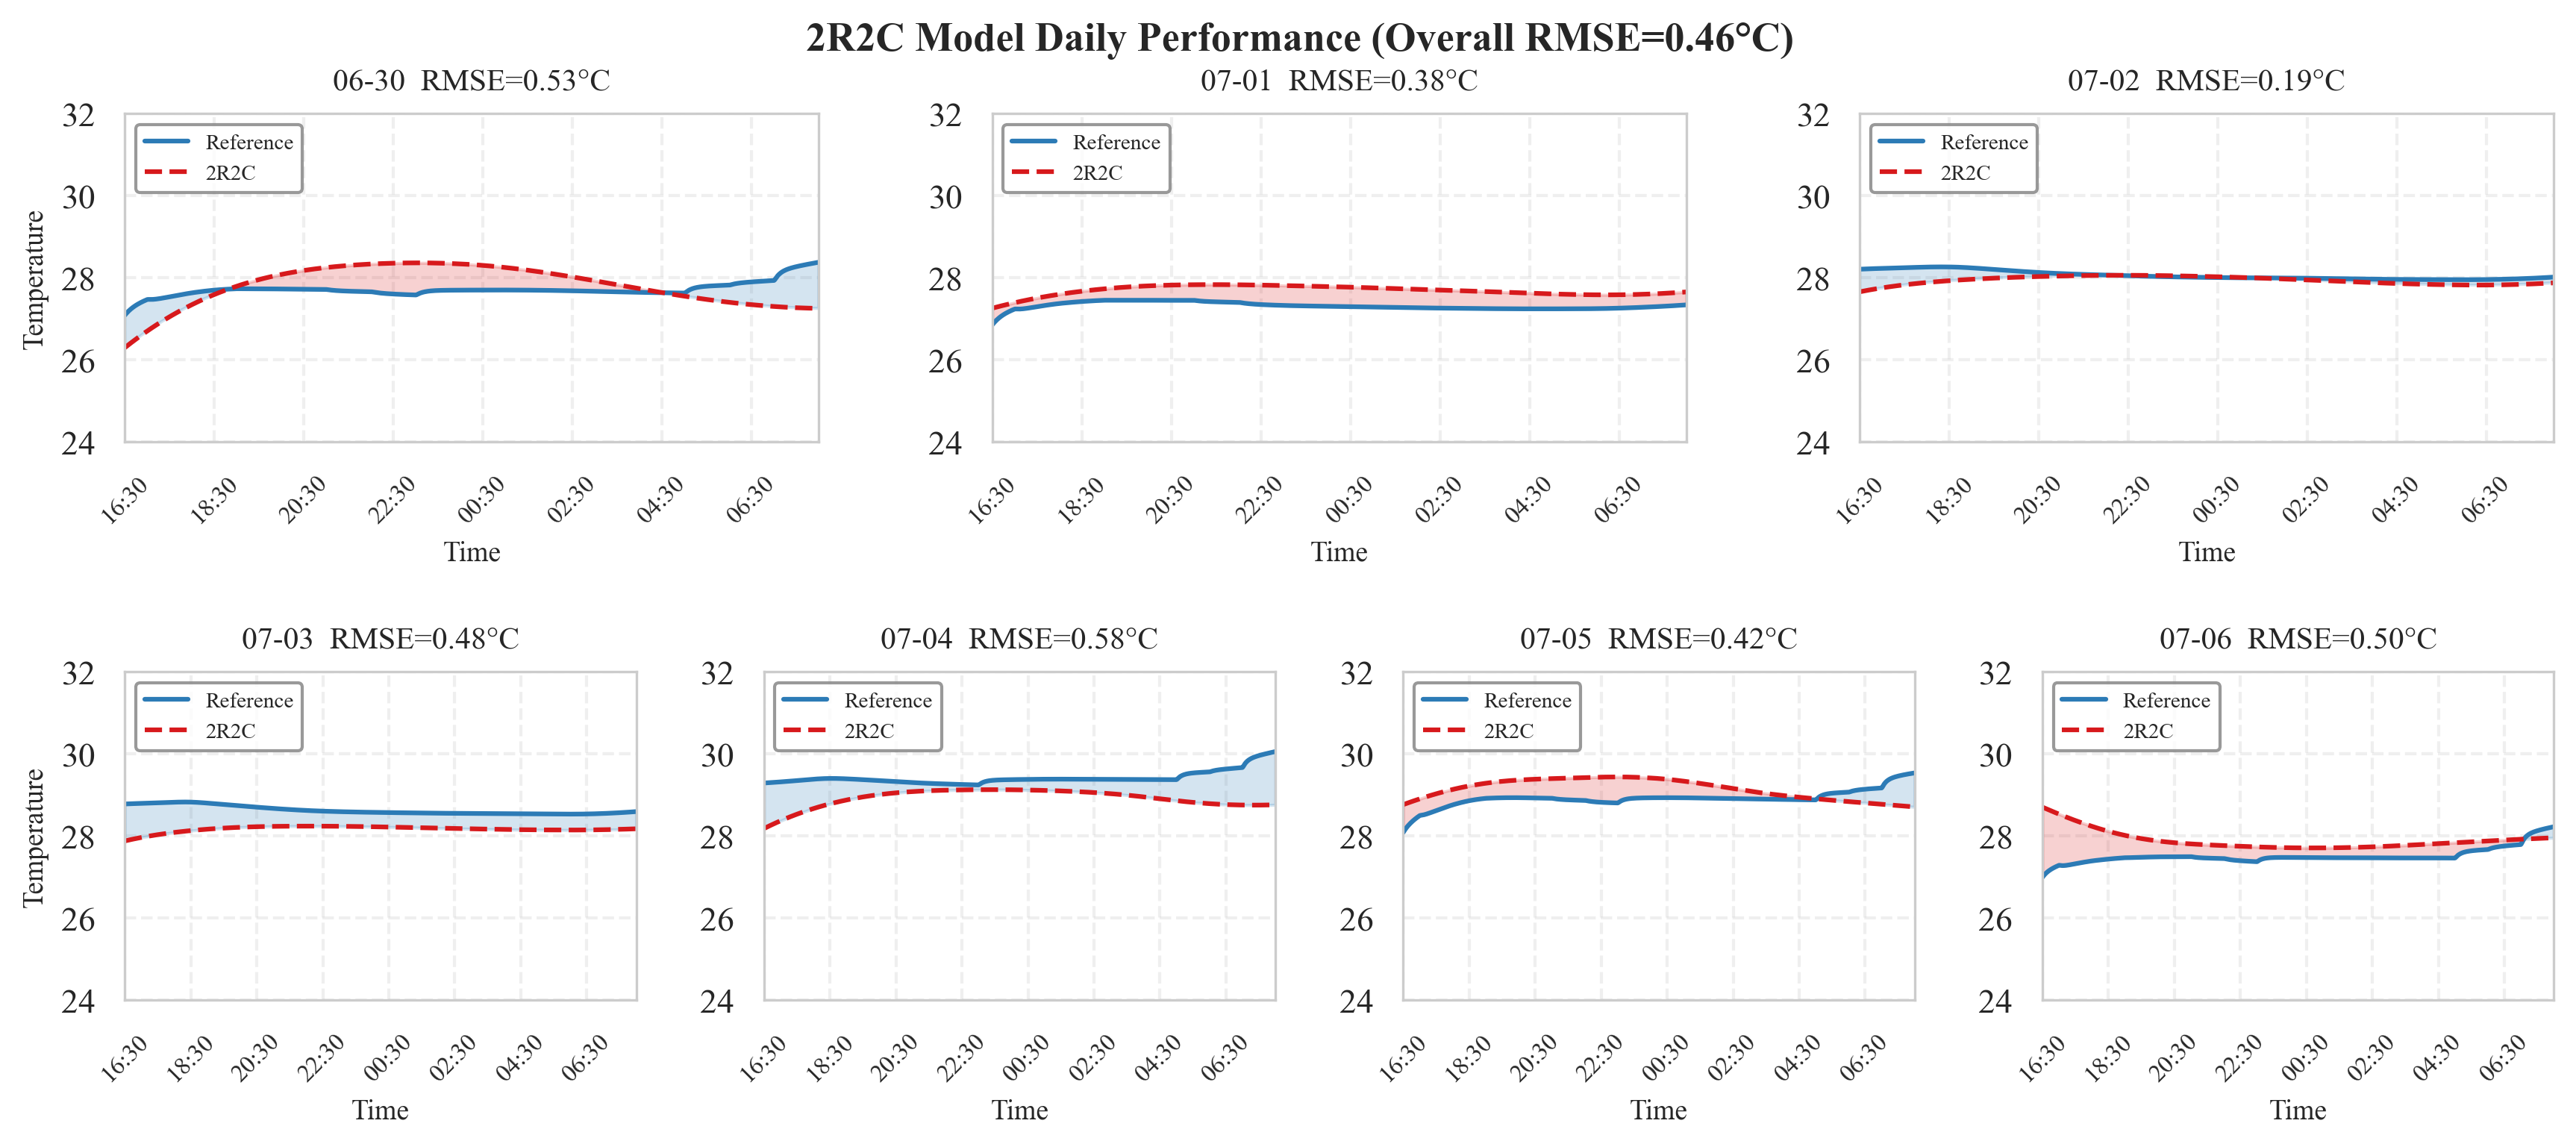

In [14]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

def save_each_subplot_legend(model, save_folder, filename="7days_each_legend.png", y_min=24, y_max=32):
    """
    每个子图独立图例（Reference, 2R2C），带残差填充，纵坐标裁剪，无室外温度。
    """
    if model is None:
        raise ValueError("model 对象不存在，请先训练模型！")
    
    cycles_to_plot = model.daily_cycles[:7]
    
    # 原纵坐标范围（18-32°C）
    orig_y_min, orig_y_max = 18, 32
    orig_span = orig_y_max - orig_y_min   # 14
    new_span = y_max - y_min               # 8
    orig_width, orig_height = 14, 9
    new_height = orig_height * (new_span / orig_span)   # 按比例缩小高度
    
    fig = plt.figure(figsize=(orig_width, new_height))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], hspace=0.7, wspace=0.25)
    gs2 = gs[1, :].subgridspec(1, 4, wspace=0.25)
    
    axs = []
    for i in range(3):
        axs.append(fig.add_subplot(gs[0, i]))
    for i in range(4):
        axs.append(fig.add_subplot(gs2[0, i]))
    
    for i, idx in enumerate(cycles_to_plot):
        ax = axs[i]
        t = model.time[idx]
        meas = model.T_i_meas[idx]
        pred = model.T_i_pred[idx]
        daily_res = pred - meas
        rmse_day = np.sqrt(np.mean(daily_res**2))
        
        cycle_start = pd.Timestamp(t[0]).replace(hour=16, minute=30, second=0)
        secs = [(pd.Timestamp(tt) - cycle_start).total_seconds() for tt in t]
        secs = np.array(secs)
        
        # 残差填充（可选，增加美观）
        ax.fill_between(secs, meas, pred, where=(pred > meas), 
                        color='#D7191C', alpha=0.2, interpolate=True, label='_nolegend_')
        ax.fill_between(secs, meas, pred, where=(pred <= meas), 
                        color='#2C7BB6', alpha=0.2, interpolate=True, label='_nolegend_')
        
        # 实测和预测曲线
        ax.plot(secs, meas, color='#2C7BB6', lw=1.5, label='Reference')
        ax.plot(secs, pred, color='#D7191C', lw=1.5, ls='--', label='2R2C')
        
        ax.set_ylim(y_min, y_max)
        date_str = cycle_start.strftime('%m-%d')
        ax.set_title(f'{date_str}  RMSE={rmse_day:.2f}°C', fontsize=10, pad=8)
        ax.grid(True, alpha=0.3)
        if i == 0 or i == 3:
            ax.set_ylabel('Temperature', fontsize=9)
        
        # 横坐标刻度
        tick_seconds = np.arange(0, 55801, 7200)
        tick_labels = []
        for sec in tick_seconds:
            total_min = 16*60 + 30 + sec/60
            hour = int(total_min // 60) % 24
            minute = int(total_min % 60)
            tick_labels.append(f'{hour:02d}:{minute:02d}')
        ax.set_xticks(tick_seconds)
        ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)
        ax.set_xlim(0, 55800)
        ax.set_xlabel('Time', fontsize=9)
        
        # 图例：放置在不遮挡曲线的位置（例如左上角或右下角，根据数据动态调整）
        # 由于曲线通常在中间区域，选择 'upper left' 或 'lower left' 可能较好
        ax.legend(fontsize=7, loc='upper left', framealpha=0.8, edgecolor='gray')
    
    overall_rmse = np.sqrt(np.mean(model.residuals**2))
    fig.suptitle(f'2R2C Model Daily Performance (Overall RMSE={overall_rmse:.2f}°C)',
                 fontsize=13, fontweight='bold', y=0.96)
    plt.tight_layout()
    
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, filename)
    plt.savefig(save_path, bbox_inches='tight', dpi=600)
    print(f"图片已保存: {save_path}")
    plt.show()

# 使用示例
save_folder = r"C:\Users\TR\Desktop\Postgraduate\Paper\EAB\figure"
save_each_subplot_legend(model, save_folder, filename="7days_each_legend.png", y_min=24, y_max=32)

图片已保存: C:\Users\TR\Desktop\Postgraduate\Paper\二区\figure\7days_each_legend_solid.png


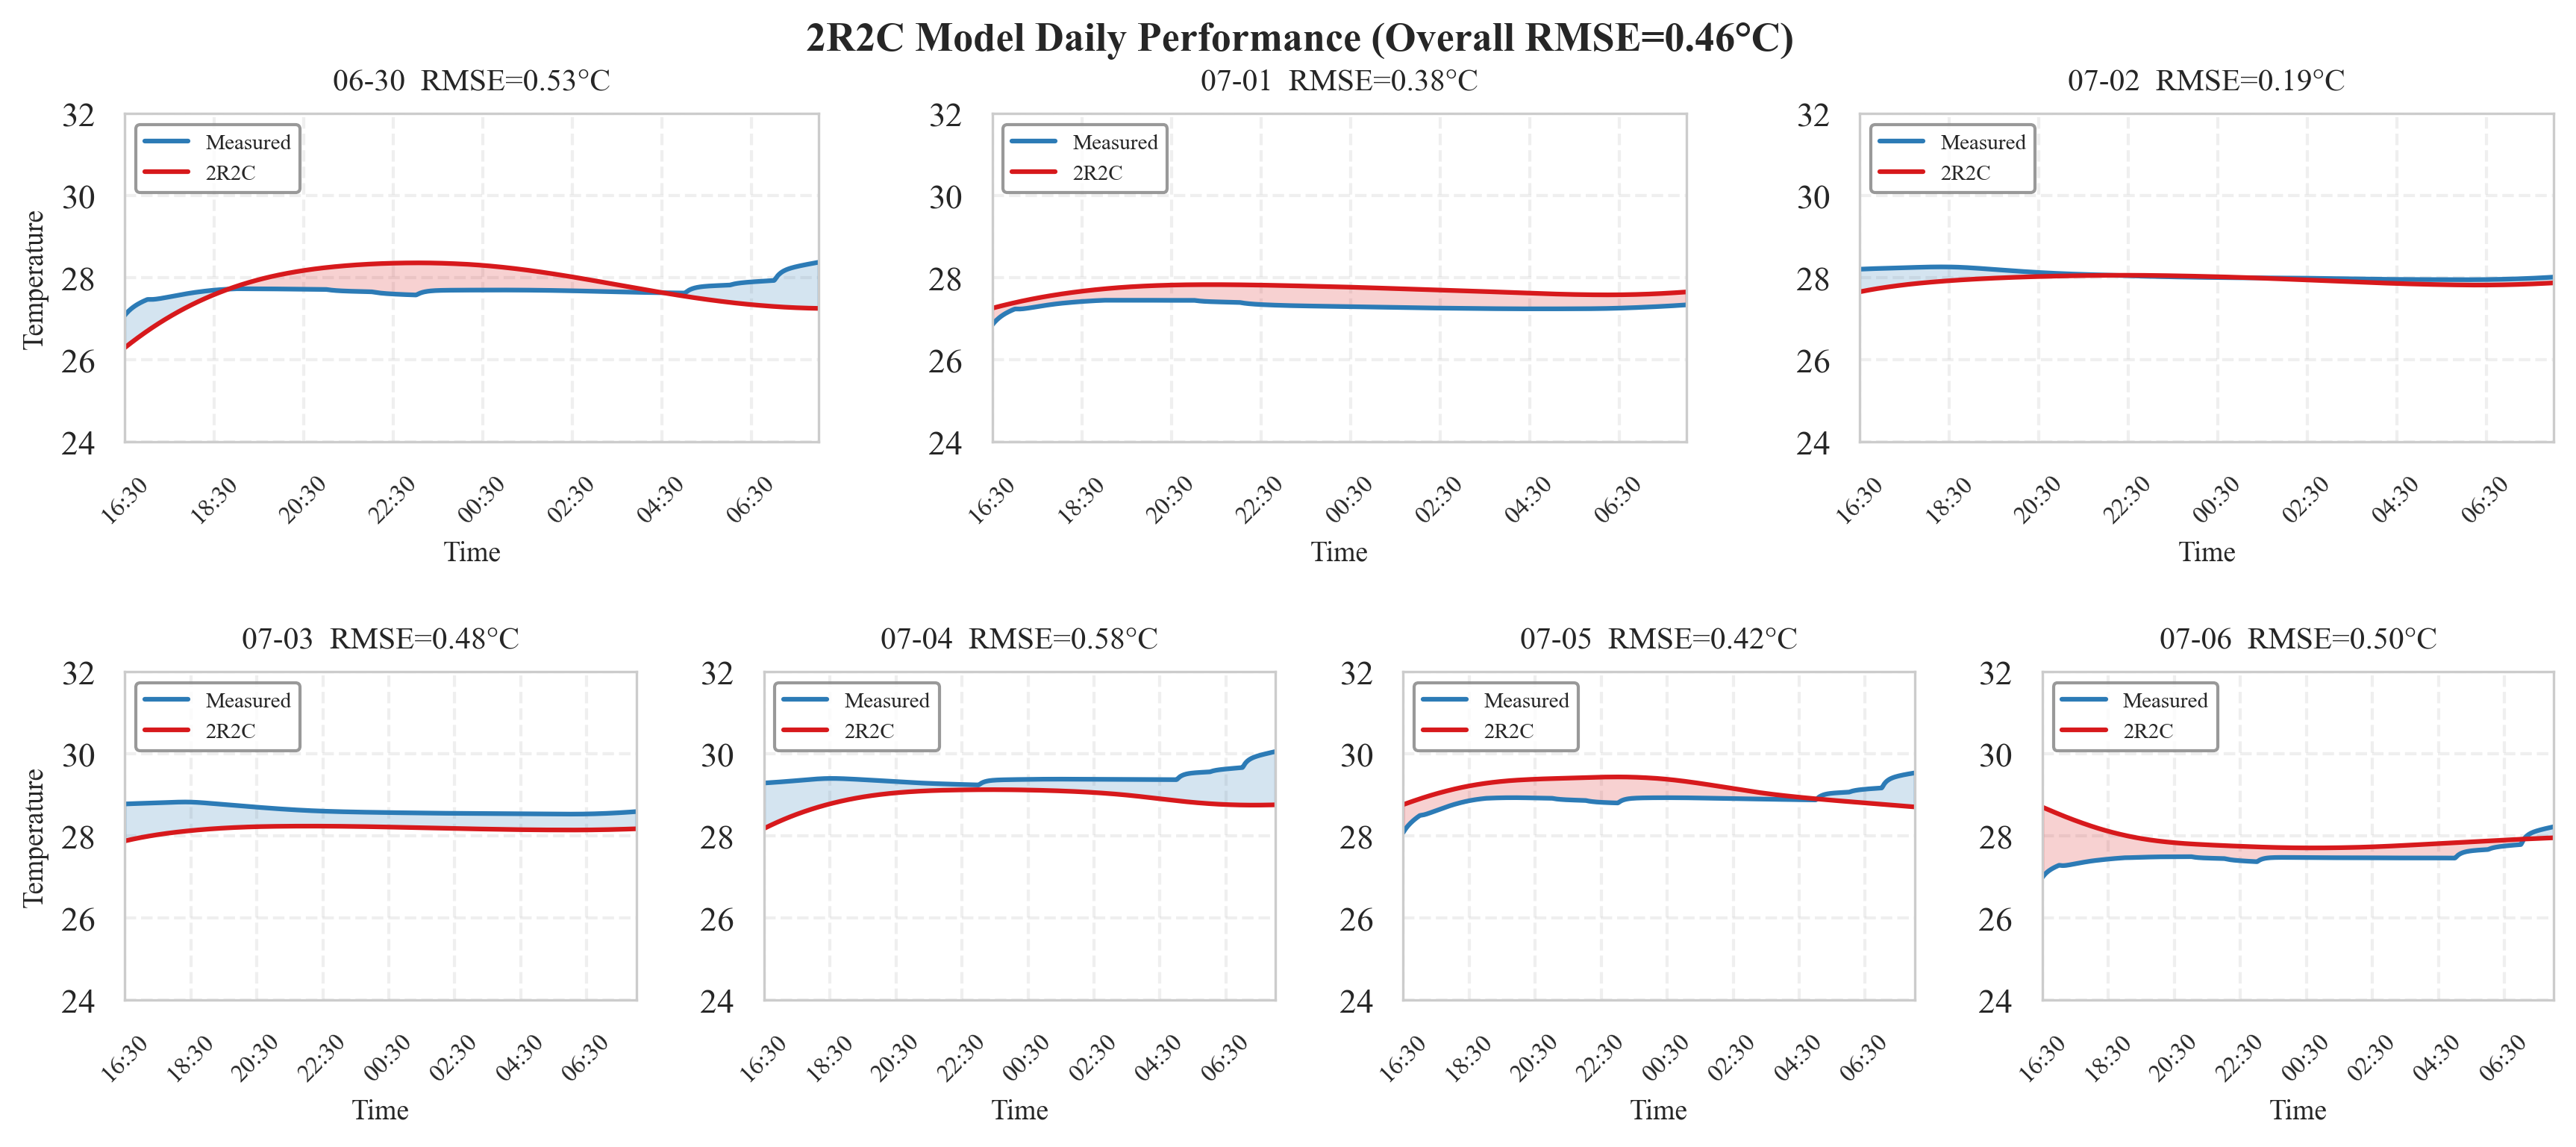

In [12]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

def save_each_subplot_legend(model, save_folder, filename="7days_each_legend.png", y_min=24, y_max=32):
    """
    每个子图独立图例（Measured, 2R2C），带残差填充，纵坐标裁剪，无室外温度。
    预测曲线为实线（原虚线已改为实线）。
    """
    if model is None:
        raise ValueError("model 对象不存在，请先训练模型！")
    
    cycles_to_plot = model.daily_cycles[:7]
    
    # 原纵坐标范围（18-32°C）
    orig_y_min, orig_y_max = 18, 32
    orig_span = orig_y_max - orig_y_min   # 14
    new_span = y_max - y_min               # 8
    orig_width, orig_height = 14, 9
    new_height = orig_height * (new_span / orig_span)   # 按比例缩小高度
    
    fig = plt.figure(figsize=(orig_width, new_height))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], hspace=0.7, wspace=0.25)
    gs2 = gs[1, :].subgridspec(1, 4, wspace=0.25)
    
    axs = []
    for i in range(3):
        axs.append(fig.add_subplot(gs[0, i]))
    for i in range(4):
        axs.append(fig.add_subplot(gs2[0, i]))
    
    for i, idx in enumerate(cycles_to_plot):
        ax = axs[i]
        t = model.time[idx]
        meas = model.T_i_meas[idx]
        pred = model.T_i_pred[idx]
        daily_res = pred - meas
        rmse_day = np.sqrt(np.mean(daily_res**2))
        
        cycle_start = pd.Timestamp(t[0]).replace(hour=16, minute=30, second=0)
        secs = [(pd.Timestamp(tt) - cycle_start).total_seconds() for tt in t]
        secs = np.array(secs)
        
        # 残差填充
        ax.fill_between(secs, meas, pred, where=(pred > meas), 
                        color='#D7191C', alpha=0.2, interpolate=True, label='_nolegend_')
        ax.fill_between(secs, meas, pred, where=(pred <= meas), 
                        color='#2C7BB6', alpha=0.2, interpolate=True, label='_nolegend_')
        
        # 实测和预测曲线（预测改为实线）
        ax.plot(secs, meas, color='#2C7BB6', lw=1.5, label='Measured')
        ax.plot(secs, pred, color='#D7191C', lw=1.5, ls='-', label='2R2C')   # 此处改为实线
        
        ax.set_ylim(y_min, y_max)
        date_str = cycle_start.strftime('%m-%d')
        ax.set_title(f'{date_str}  RMSE={rmse_day:.2f}°C', fontsize=10, pad=8)
        ax.grid(True, alpha=0.3)
        if i == 0 or i == 3:
            ax.set_ylabel('Temperature', fontsize=9)
        
        # 横坐标刻度
        tick_seconds = np.arange(0, 55801, 7200)
        tick_labels = []
        for sec in tick_seconds:
            total_min = 16*60 + 30 + sec/60
            hour = int(total_min // 60) % 24
            minute = int(total_min % 60)
            tick_labels.append(f'{hour:02d}:{minute:02d}')
        ax.set_xticks(tick_seconds)
        ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)
        ax.set_xlim(0, 55800)
        ax.set_xlabel('Time', fontsize=9)
        
        # 图例
        ax.legend(fontsize=7, loc='upper left', framealpha=0.8, edgecolor='gray')
    
    overall_rmse = np.sqrt(np.mean(model.residuals**2))
    fig.suptitle(f'2R2C Model Daily Performance (Overall RMSE={overall_rmse:.2f}°C)',
                 fontsize=13, fontweight='bold', y=0.96)
    plt.tight_layout()
    
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, filename)
    plt.savefig(save_path, bbox_inches='tight', dpi=600)
    print(f"图片已保存: {save_path}")
    plt.show()

# 使用示例
save_folder = r"C:\Users\TR\Desktop\Postgraduate\Paper\二区\figure"
save_each_subplot_legend(model, save_folder, filename="7days_each_legend_solid.png", y_min=24, y_max=32)